# 02 — ECG Signal Characterization

## Objectives

The objectives of this notebook are to:

- Characterize the basic properties of ECG recordings across multiple records.
- Examine ECG signals in the time and frequency domains.
- Investigate ECG morphology and signal variability across recordings.
- Identify and characterize common noise and artifact components.
- Experiment with basic filtering techniques and observe their effects on ECG signals.
- Compare raw and filtered signals in both the time and frequency domains.
- Develop reusable and generalizable analysis procedures that can be applied to multiple ECG recordings.

## 1. Imports

In [1]:
# Import libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from scipy.signal import filtfilt, butter, iirnotch

# Define the project paths
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
MITDB_DIR = RAW_DATA_DIR / "mit-bih-arrhythmia"


## 2. Load & Inspect Samples

In [2]:
# A function to load the samples we want
def load_samples(samples_lst:list=["100"]):

    samples = []

    for name in samples_lst:
        samples.append(wfdb.rdrecord(str(MITDB_DIR / name)))

    return samples


In [3]:
# Samples to load
samples = ["100", "101", "102", "103", "104"]
# Get samples
records = load_samples(samples)

In [4]:
# Calculate some required statistics
def statistics(records_lst):

    stats = []

    for record in records_lst:
        stats.append({
            "Record": record.record_name,
            "Sampling frequency": record.fs,
            "Number of samples": record.sig_len,
            "Number of channels": record.n_sig,
            "Signal names": record.sig_name,
            "Units": record.units,
            "Length in minutes": ((record.sig_len/record.fs)/60), 
            "Shape": record.p_signal.shape,
            "Minimum": np.min(record.p_signal, axis=0),
            "Maximum": np.max(record.p_signal, axis=0),
            "Mean": np.mean(record.p_signal, axis=0),
            "Standard deviation": np.std(record.p_signal, axis=0)
        })

    return pd.DataFrame(stats)
    

In [5]:
# Get statistics
records_stats = statistics(records)
records_stats

,Record,Sampling frequency,Number of samples,Number of channels,Signal names,Units,Length in minutes,Shape,Minimum,Maximum,Mean,Standard deviation
0,100,360,650000,2,"[MLII, V5]","[mV, mV]",30.092593,"(650000, 2)","[-2.715, -2.465]","[1.435, 1.225]","[-0.30629897692306546, -0.19103443076923968]","[0.19319954213736898, 0.14821322436295903]"
1,101,360,650000,2,"[MLII, V1]","[mV, mV]",30.092593,"(650000, 2)","[-3.175, -0.565]","[2.42, 0.735]","[-0.2842219692307504, -0.0781144230769333]","[0.26115644466742366, 0.0494147737918352]"
2,102,360,650000,2,"[V5, V2]","[mV, mV]",30.092593,"(650000, 2)","[-1.66, -3.37]","[1.375, 2.535]","[-0.24585376923076718, 0.012582761538461591]","[0.19048907095947715, 1.1435078400033796]"
3,103,360,650000,2,"[MLII, V2]","[mV, mV]",30.092593,"(650000, 2)","[-2.61, -5.12]","[3.125, 5.115]","[-0.23143039230770052, 0.047015515384613356]","[0.32184030156067933, 0.6871080938684099]"
4,104,360,650000,2,"[V5, V2]","[mV, mV]",30.092593,"(650000, 2)","[-1.935, -1.77]","[1.975, 1.51]","[-0.22507546923076657, 0.07159461538461052]","[0.2503816094342726, 0.20230744475116505]"


## 3. Time-Domain Analysis

In [6]:
def plot_entire_time_record(record):
    time = np.arange(record.sig_len) / record.fs    # Calculate time intervals

    plt.figure(figsize=(15, 7))

    plt.subplot(2, 1, 1)
    plt.plot(time, record.p_signal[:, 0], color="#b73347")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.title(f"Record {record.record_name} — Raw ECG - Channel 1")
    plt.grid()

    plt.subplot(2, 1, 2)
    plt.plot(time, record.p_signal[:, 1], color="#b73347")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.title(f"Record {record.record_name} — Raw ECG - Channel 2")
    plt.grid()

    plt.tight_layout()
    plt.show()

    return time



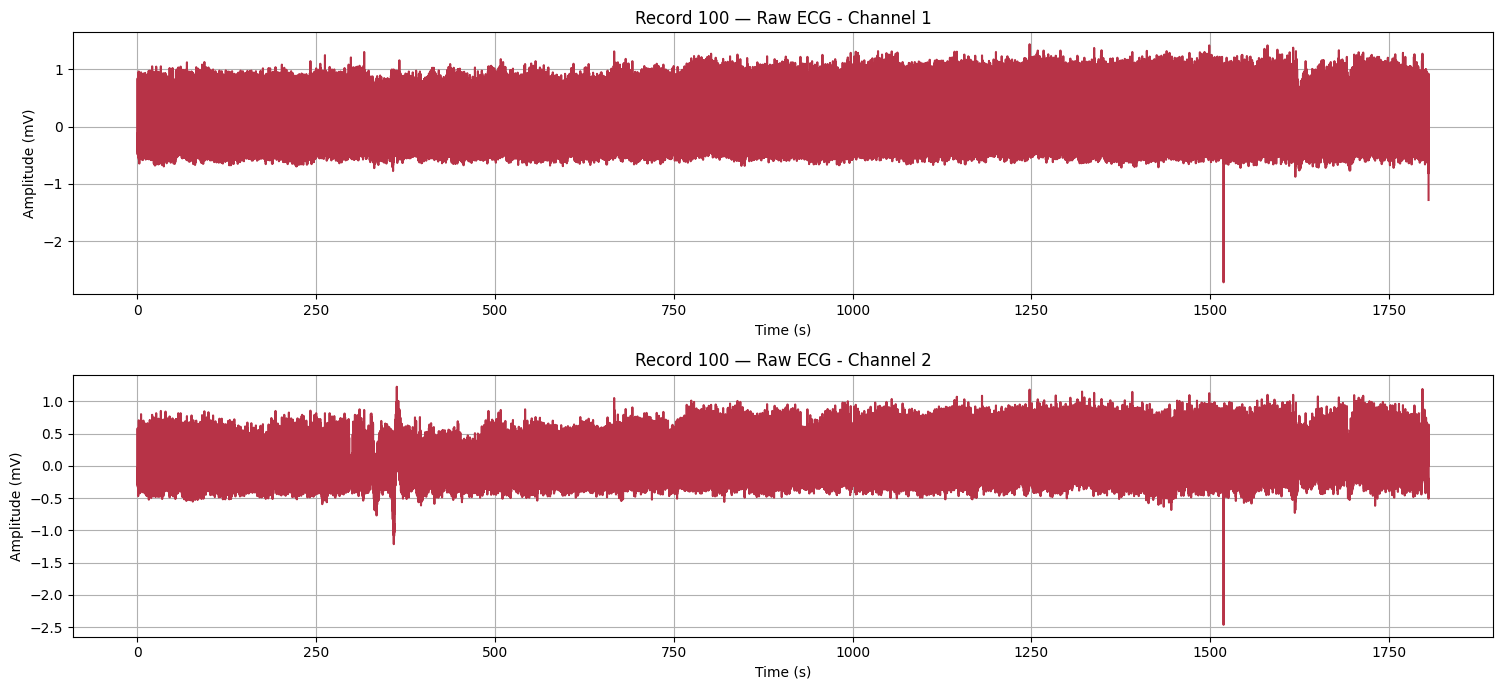

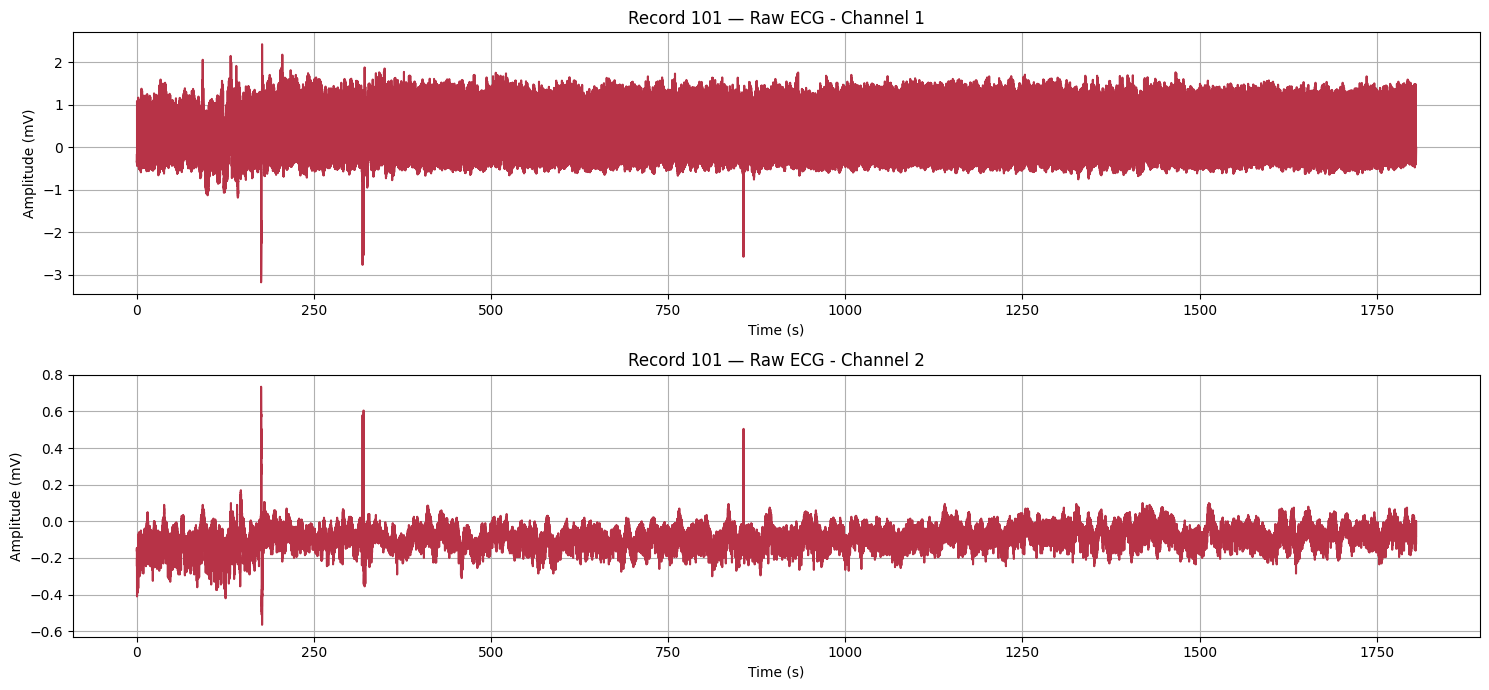

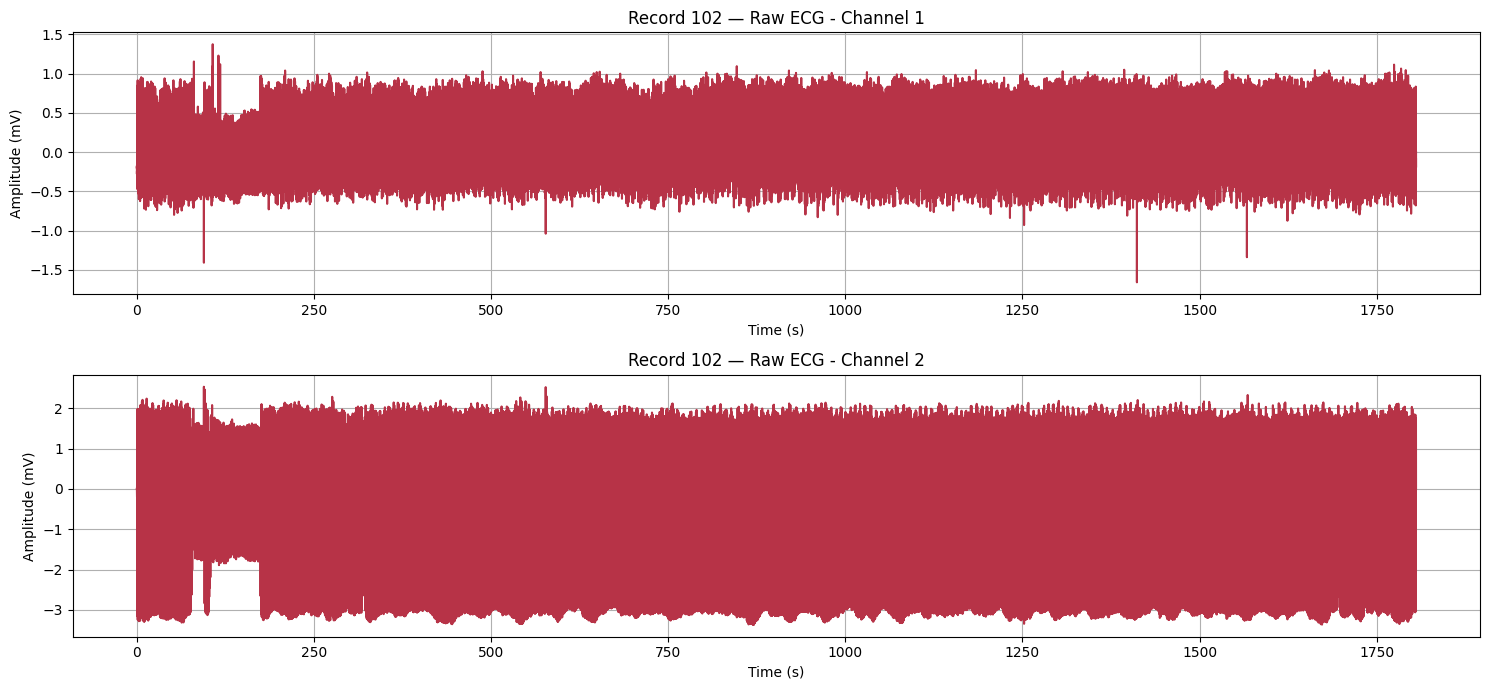

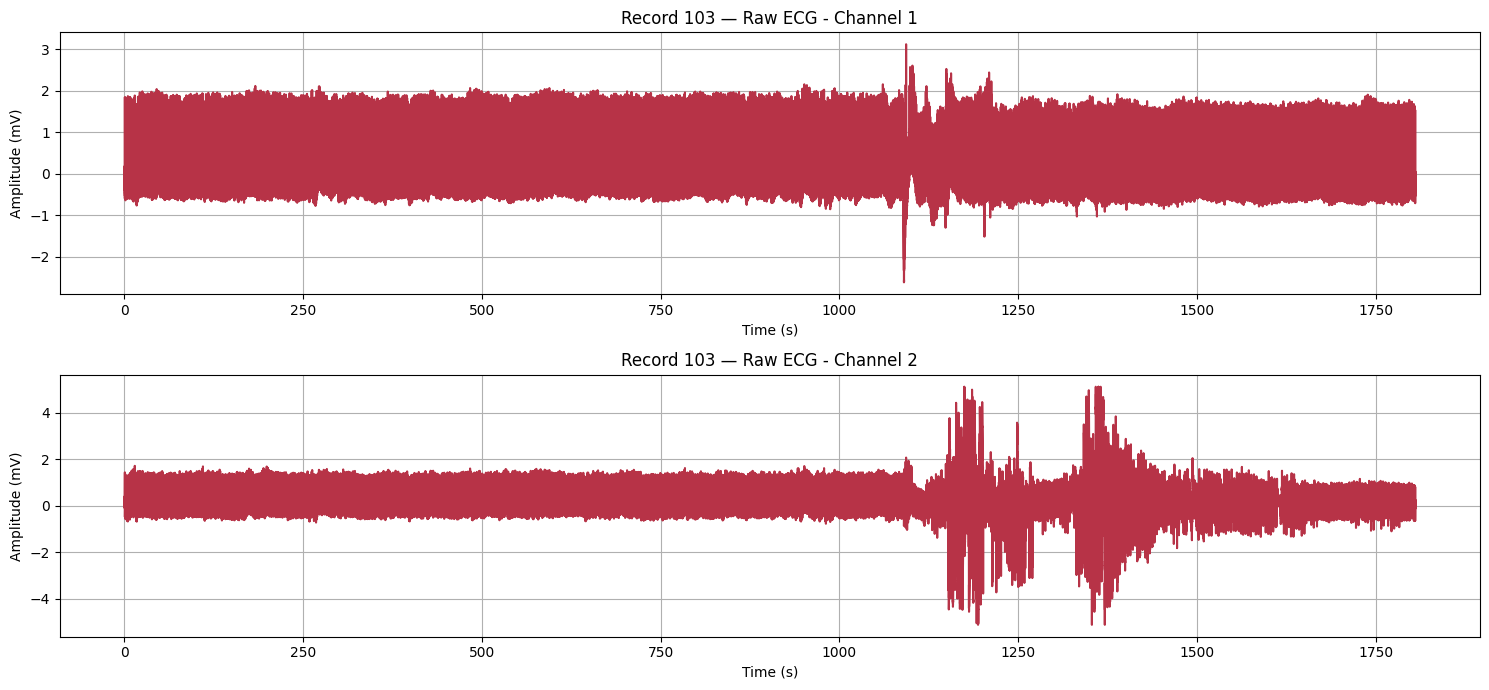

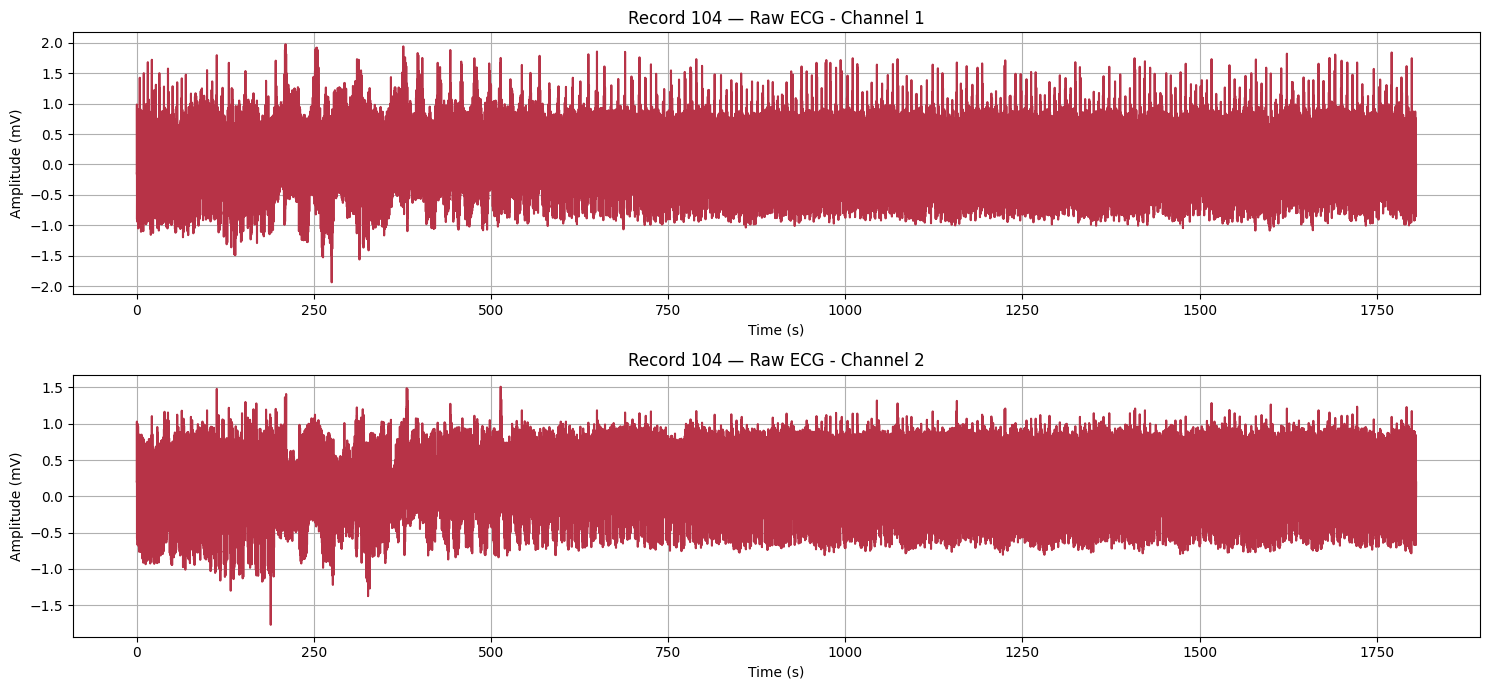

In [7]:
time_100 = plot_entire_time_record(records[0])
time_101 = plot_entire_time_record(records[1])
time_102 = plot_entire_time_record(records[2])
time_103 = plot_entire_time_record(records[3])
time_104 = plot_entire_time_record(records[4])

In [8]:
def plot_short_seg_time(record, time, start_time=0,
                         end_time=10, c1="#792180", c2="#212E80"):

    start_sample = int(start_time * record.fs)
    end_sample = int(end_time * record.fs)

    segment1 = record.p_signal[start_sample:end_sample, 0]
    segment2 = record.p_signal[start_sample:end_sample, 1]
    segment_time = time[start_sample:end_sample]

    plt.figure(figsize=(15, 5))

    plt.subplot(2, 1, 1)
    plt.plot(segment_time, segment1, color=c1)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.title(f"Record {record.record_name} — {start_time} to {end_time} Seconds - Channel 1")
    plt.grid()

    plt.subplot(2, 1, 2)
    plt.plot(segment_time, segment2, color=c2)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.title(f"Record {record.record_name} — {start_time} to {end_time} Seconds - Channel 2")
    plt.grid()

    plt.tight_layout()
    plt.show()


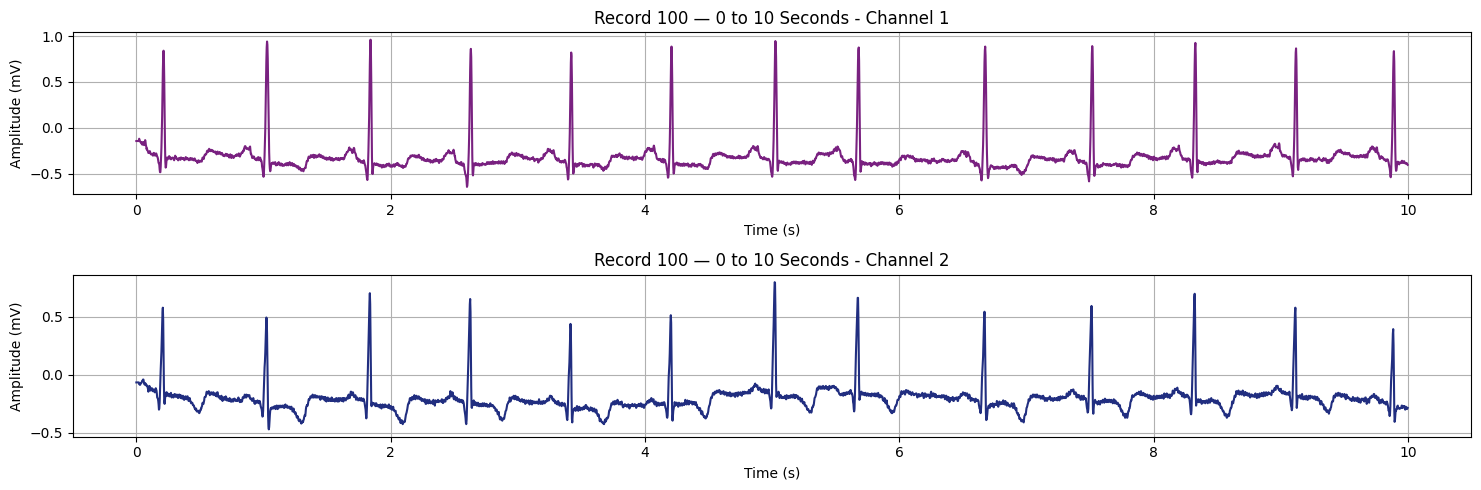

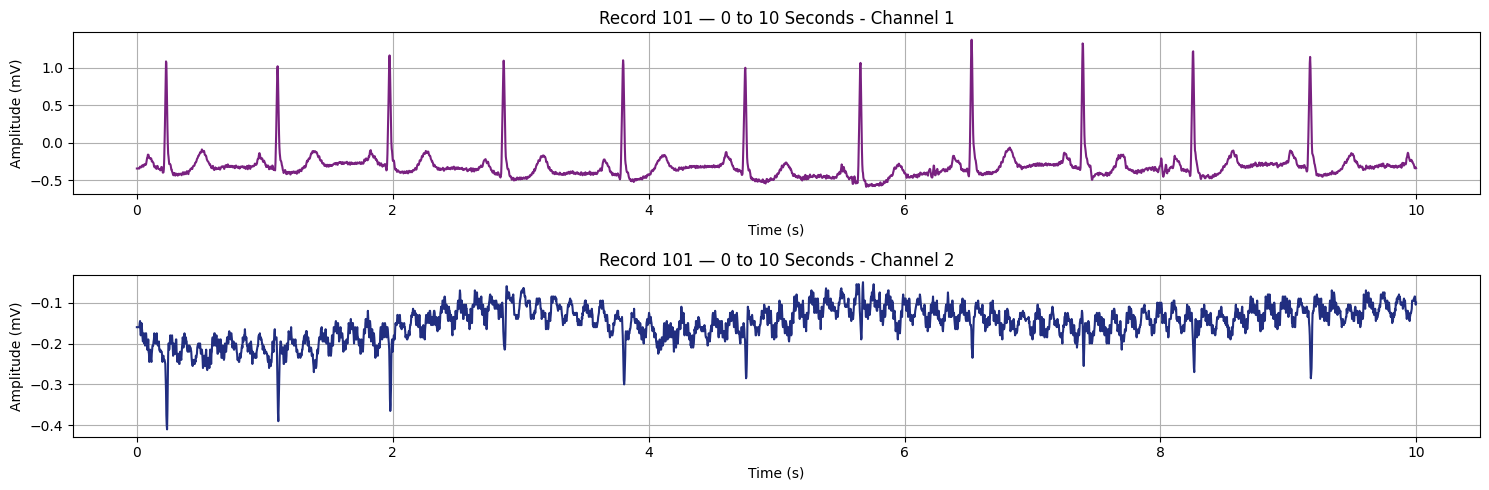

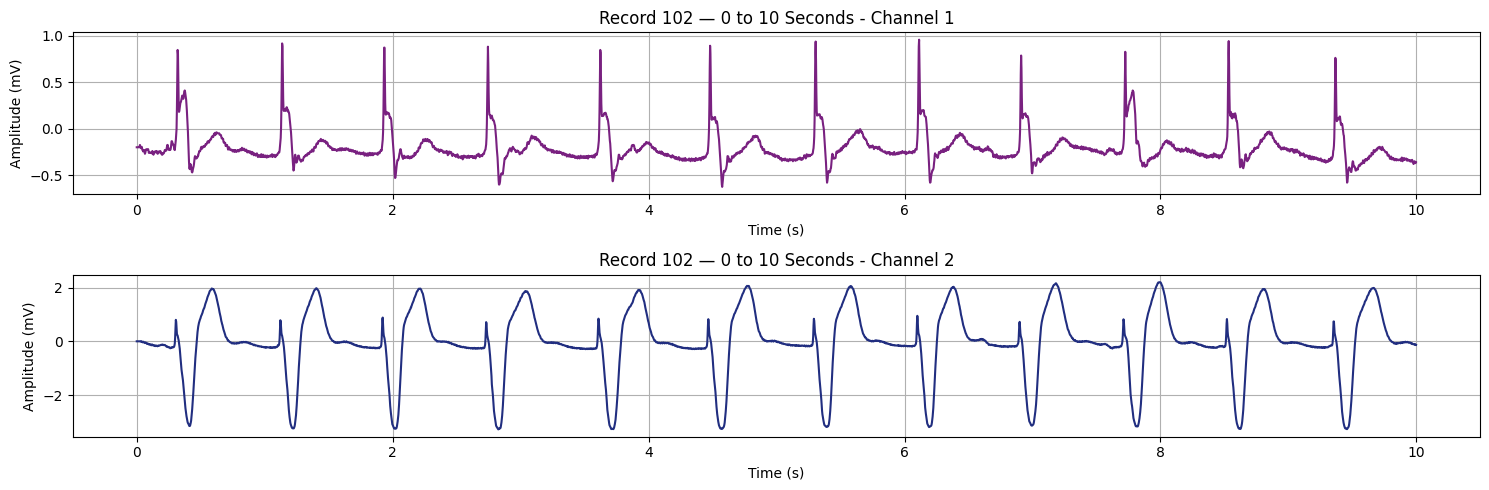

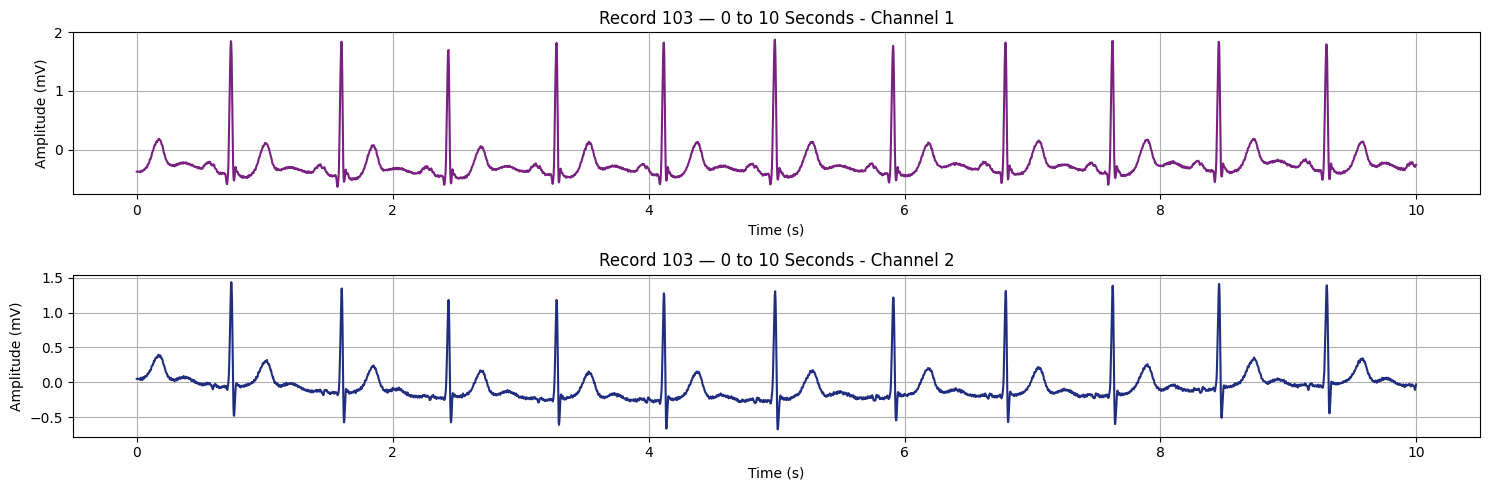

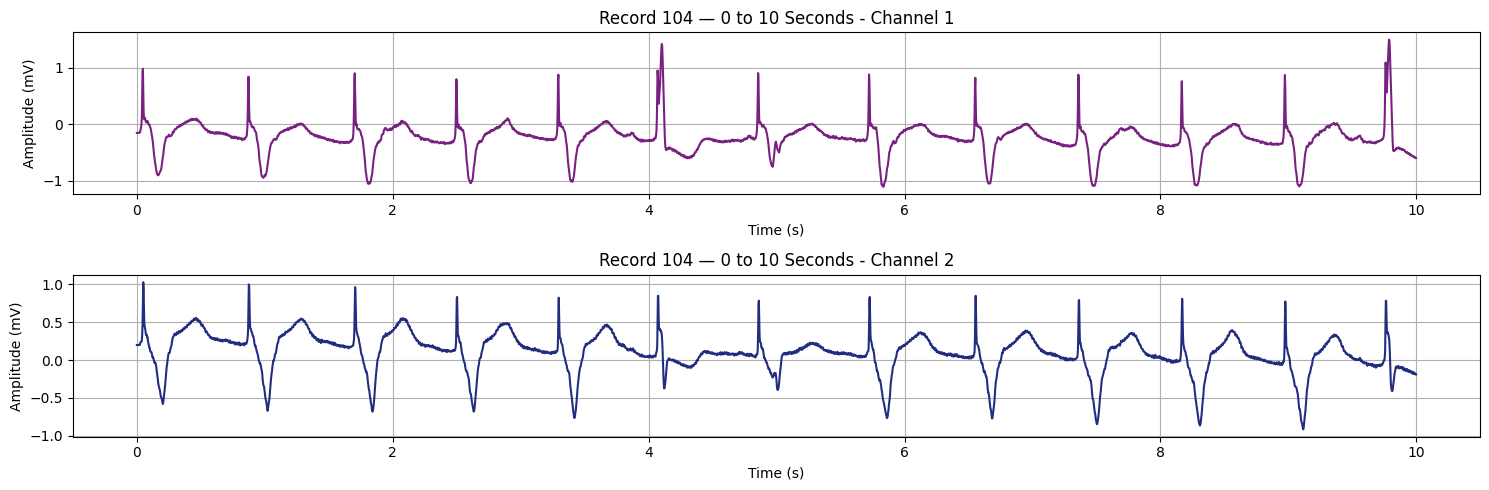

In [ ]:
# Plot first 10 seconds of the records
plot_short_seg_time(records[0], time_100)
plot_short_seg_time(records[1], time_101)
plot_short_seg_time(records[2], time_102)
plot_short_seg_time(records[3], time_103)
plot_short_seg_time(records[4], time_104)

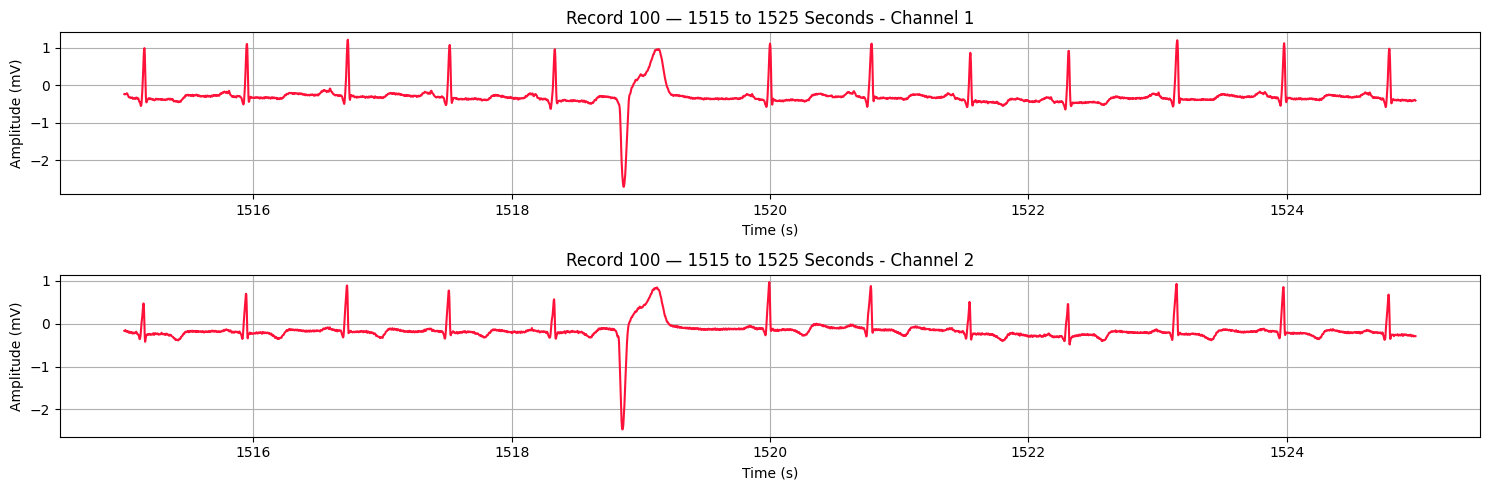

In [34]:
# specific area of record 100
c = "#ff1239"
plot_short_seg_time(records[0], time_100, 1515, 1525, c1=c, c2=c)

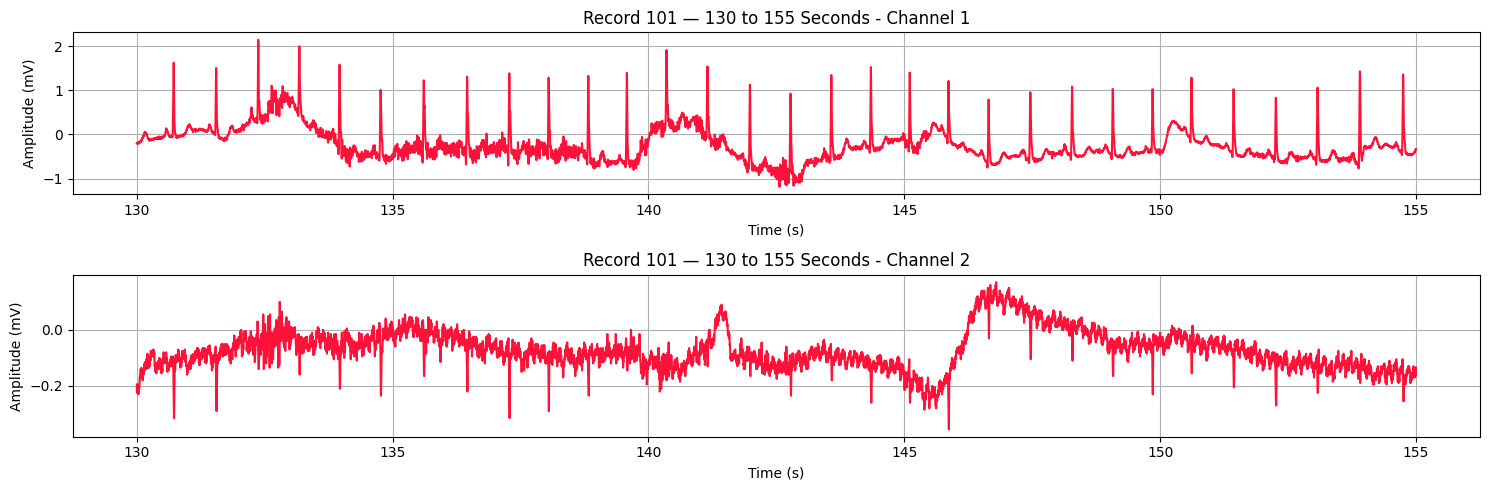

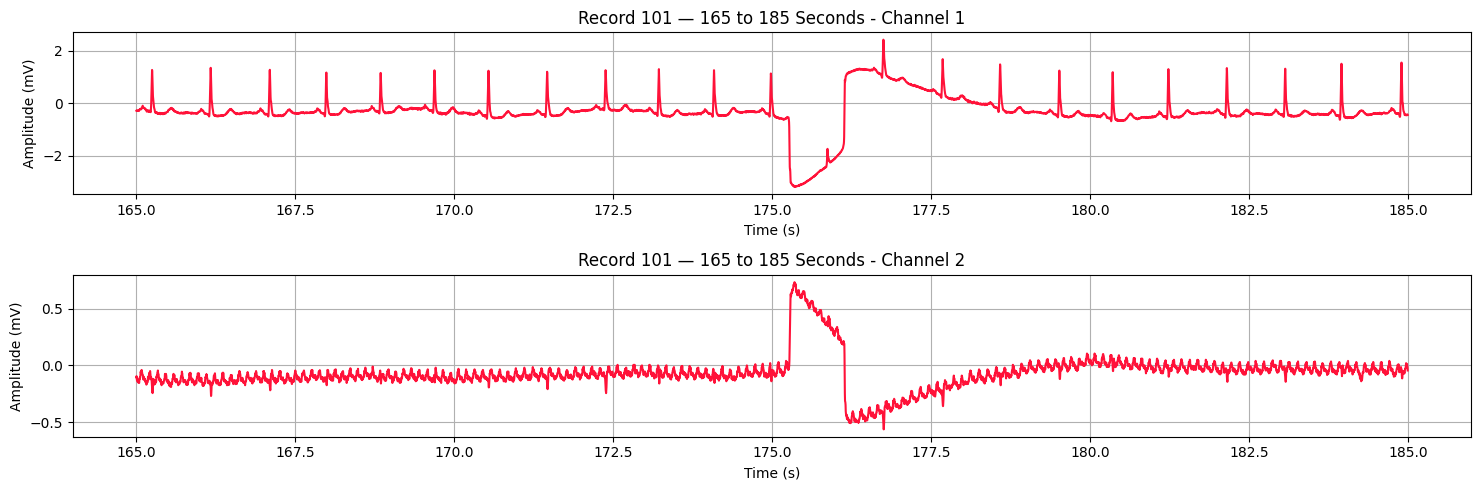

In [39]:
# specific area of record 101
plot_short_seg_time(records[1], time_101, 130, 155, c, c)
plot_short_seg_time(records[1], time_101, 165, 185, c, c)

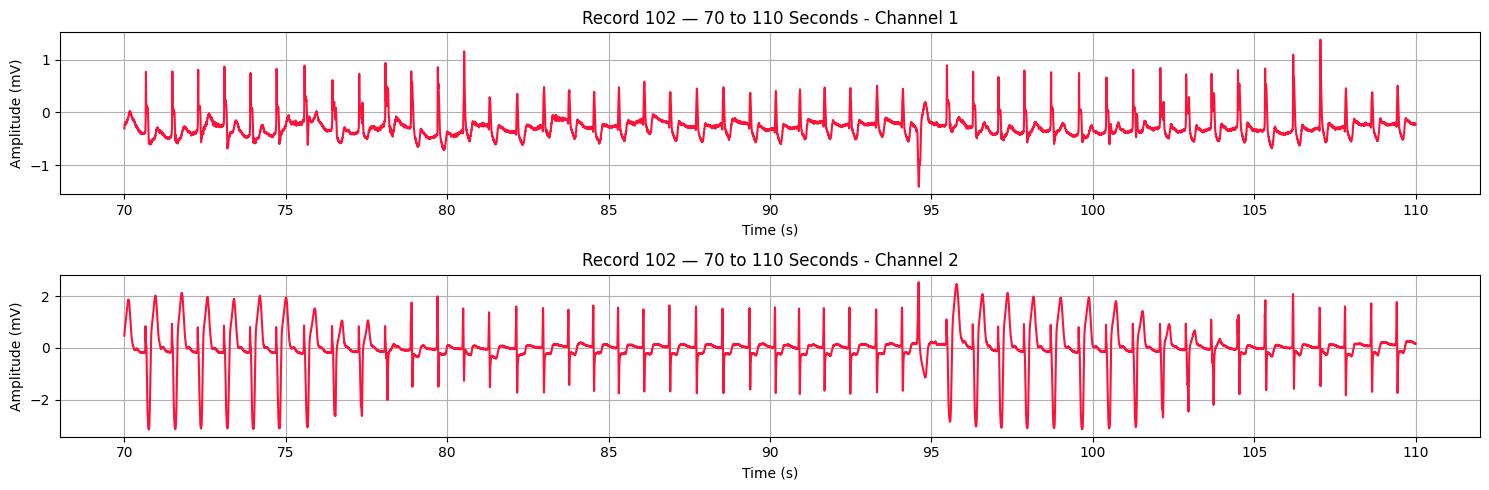

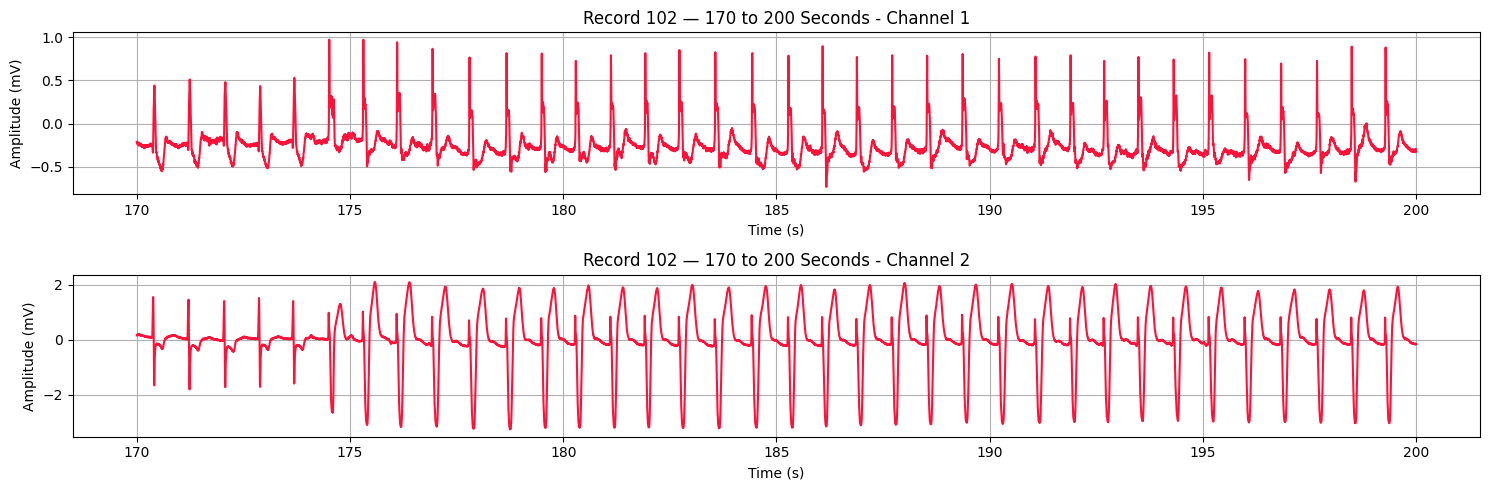

In [42]:
# Specific areas of record 102
plot_short_seg_time(records[2], time_102, 70, 110, c, c)
plot_short_seg_time(records[2], time_102, 170, 200, c, c)

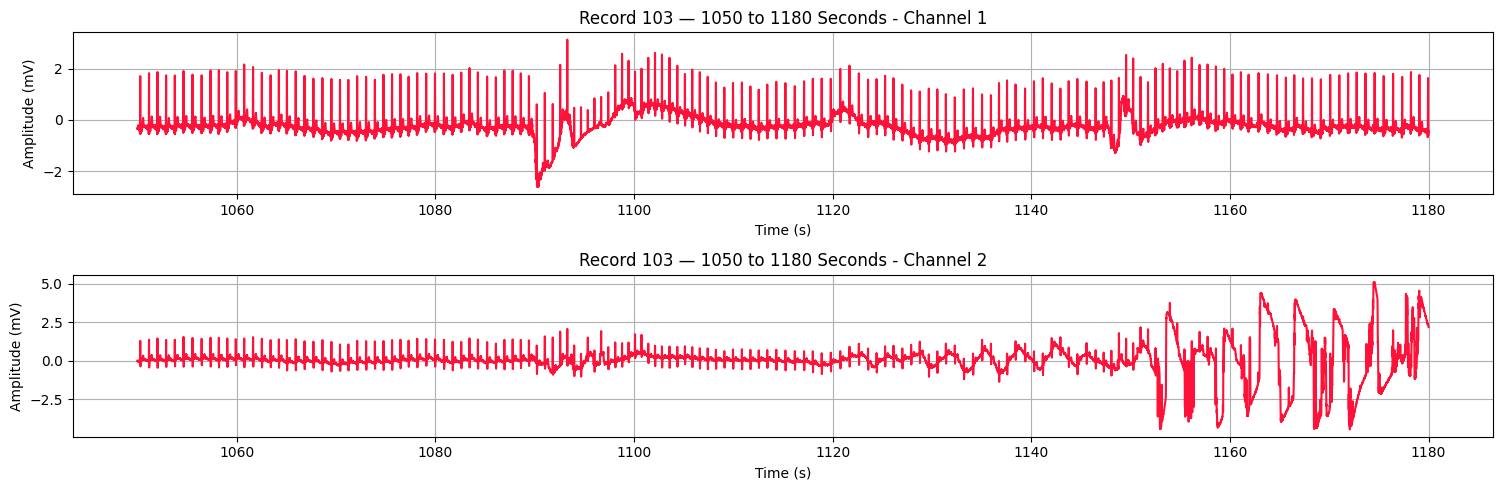

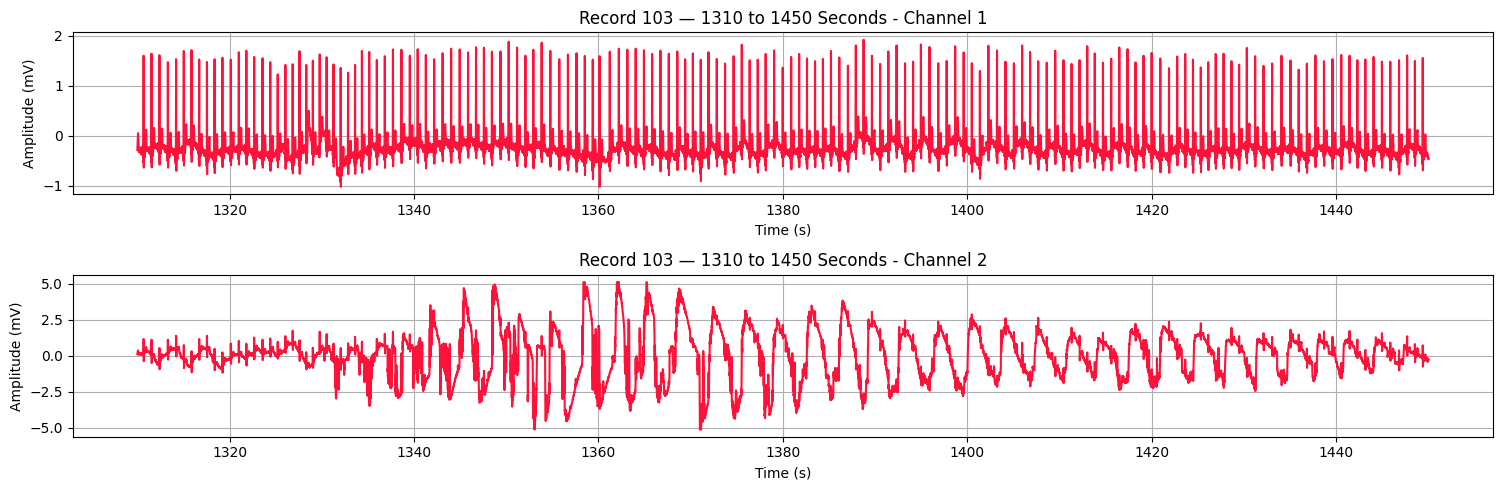

In [44]:
# Specific areas of record 103
plot_short_seg_time(records[3], time_103, 1050, 1180, c, c)
plot_short_seg_time(records[3], time_103, 1310, 1450, c, c)

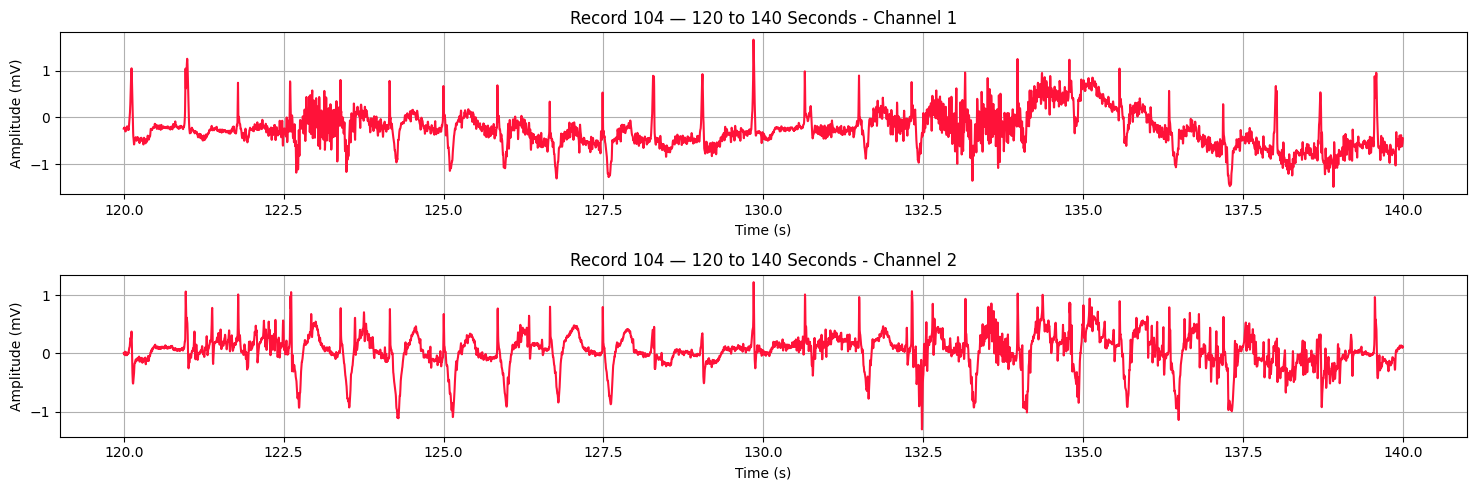

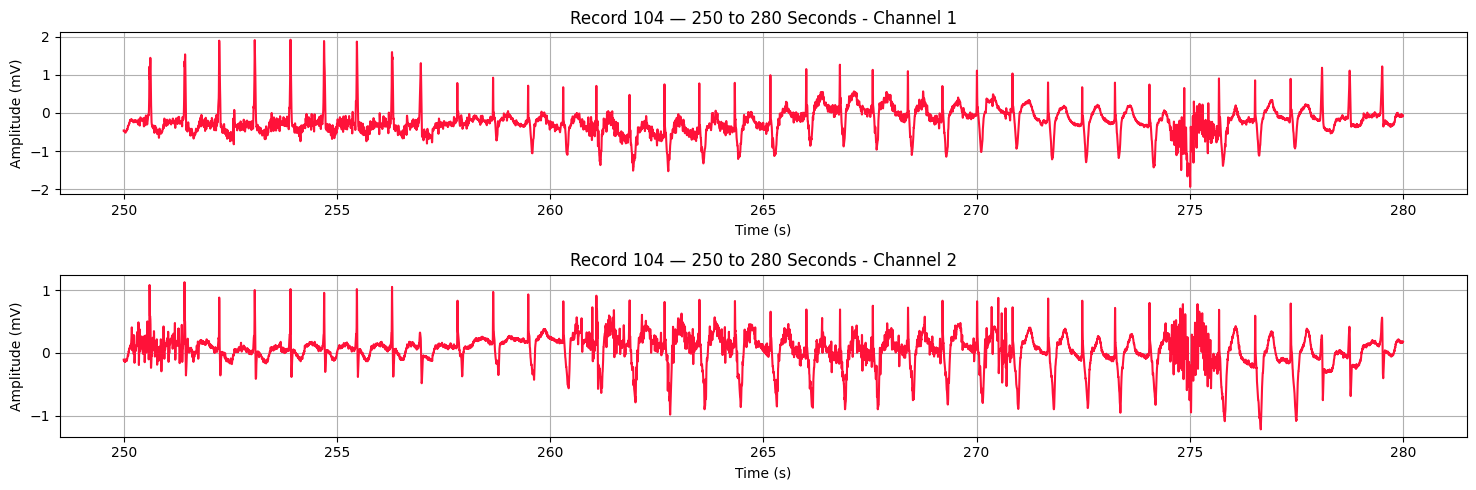

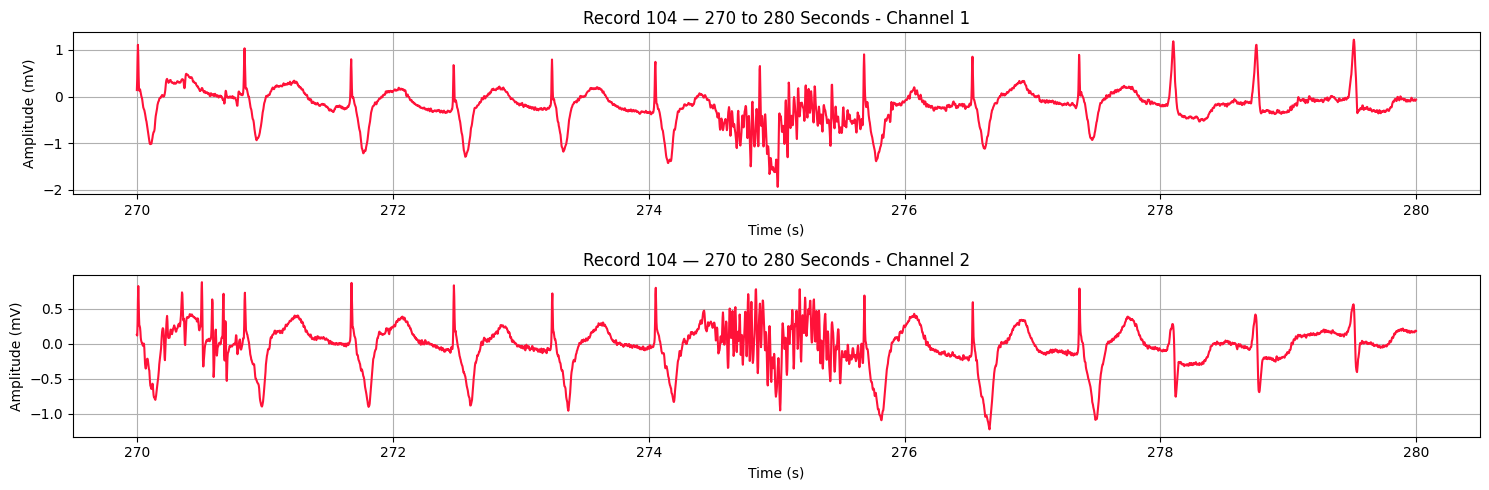

In [48]:
# Specific areas of record 104
plot_short_seg_time(records[4], time_104, 120, 140, c, c)
plot_short_seg_time(records[4], time_104, 250, 280, c, c)
plot_short_seg_time(records[4], time_104, 270, 280, c, c)

## 4. Frequensy-Domain Analysis

In [9]:
def fft_analysis(signal, record):
    fft_result = np.fft.fft(signal)
    frequencies = np.fft.fftfreq(len(signal), d=1 / record.fs)
    magnitude = np.abs(fft_result) * 2.0 / len(signal)
    positive = frequencies >= 0

    return frequencies, magnitude, positive


def plot_freq_spectrum(record, start_time, end_time,
                       c1="#ff2200", c2="#0000ff"):

    start_sample = int(start_time * record.fs)
    end_sample = int(end_time * record.fs)

    segment1 = record.p_signal[start_sample:end_sample, 0]
    segment2 = record.p_signal[start_sample:end_sample, 1]
        
    freq1, mag1, pos1 = fft_analysis(segment1, record)
    freq2, mag2, pos2 = fft_analysis(segment2, record)

    if start_time == 0 and end_time == record.sig_len / record.fs:
        txt = 'Entire Recording'
    else:
        txt = f'{start_time} to {end_time} Seconds'

    plt.figure(figsize=(15, 6))

    plt.subplot(3, 1, 1)
    plt.plot(freq1[pos1], mag1[pos1], color=c1)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.title(f"Record {record.record_name} — ECG Frequency Spectrum - {txt} - Channel 1")
    plt.grid()

    plt.subplot(3, 1, 2)
    plt.plot(freq2[pos2], mag2[pos2], color=c2)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.title(f"Record {record.record_name} — ECG Frequency Spectrum - {txt} - Channel 2")
    plt.grid()

    plt.subplot(3, 1, 3)
    plt.plot(freq1[pos1], mag1[pos1], label="Channel 1", color=c1)
    plt.plot(freq2[pos2], mag2[pos2], label="Channel 2", color=c2)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.title(f"Record {record.record_name} — Frequency Spectrum of Both Channels - {txt}")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()



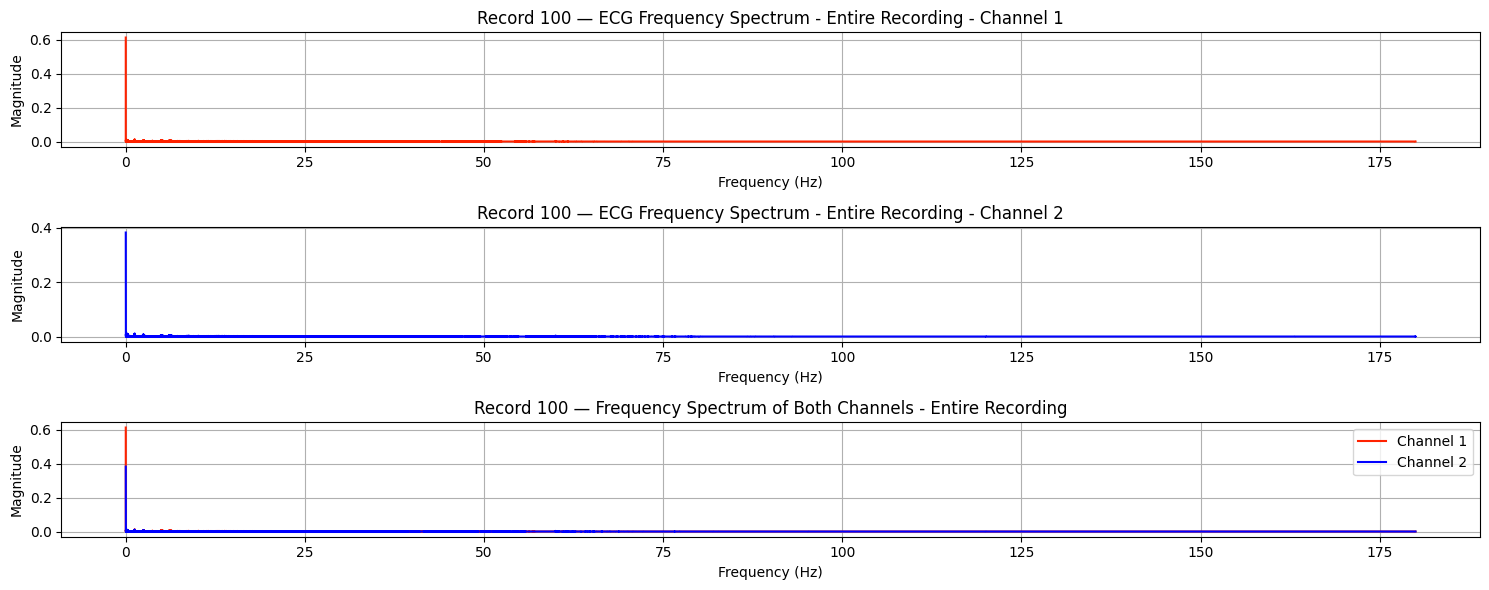

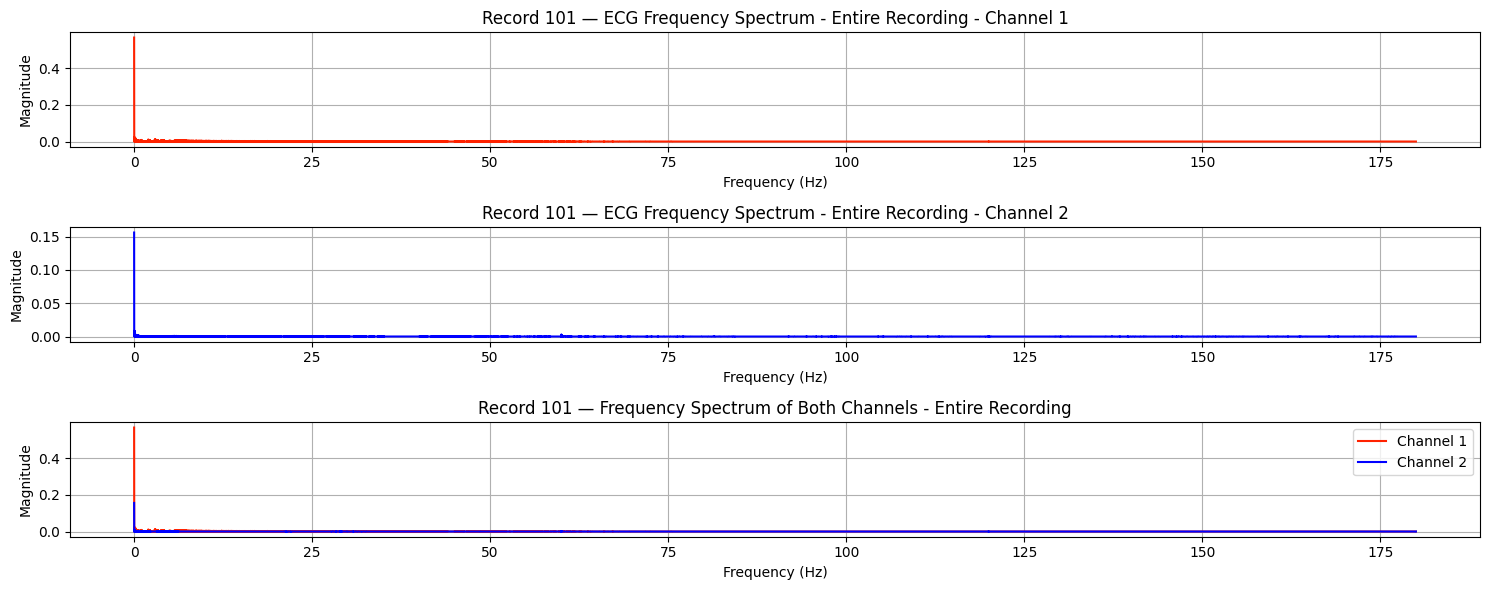

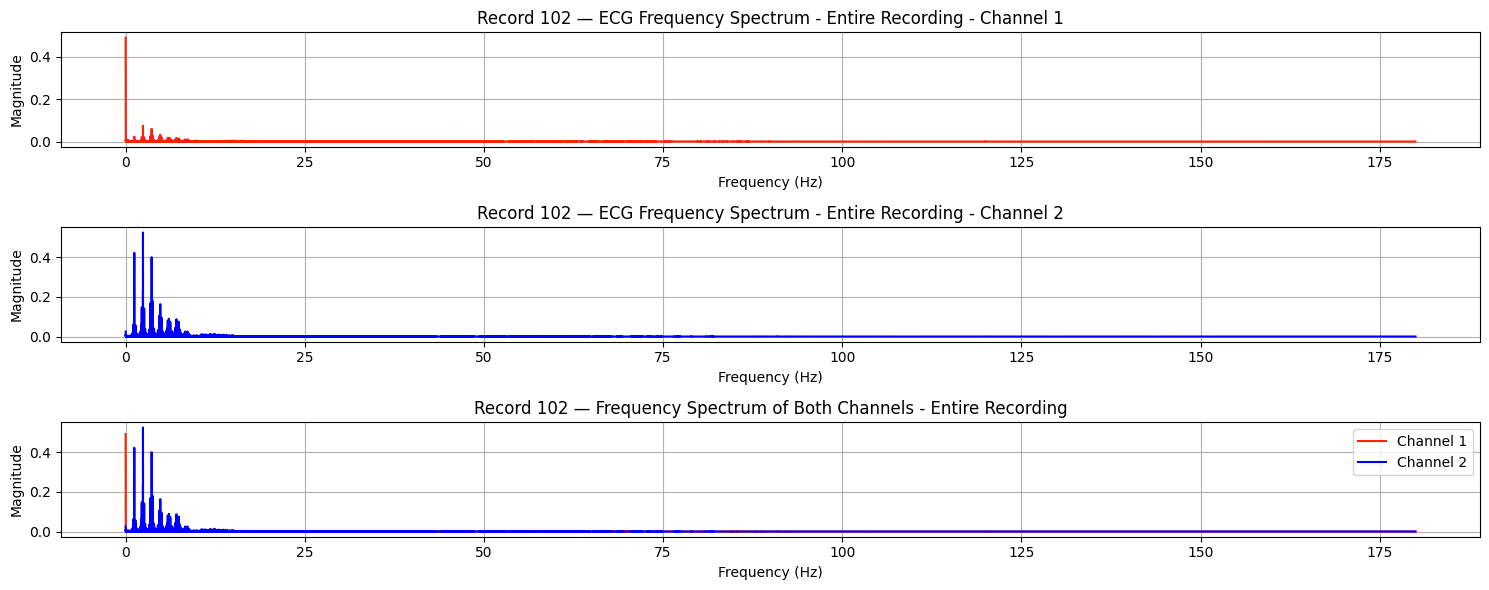

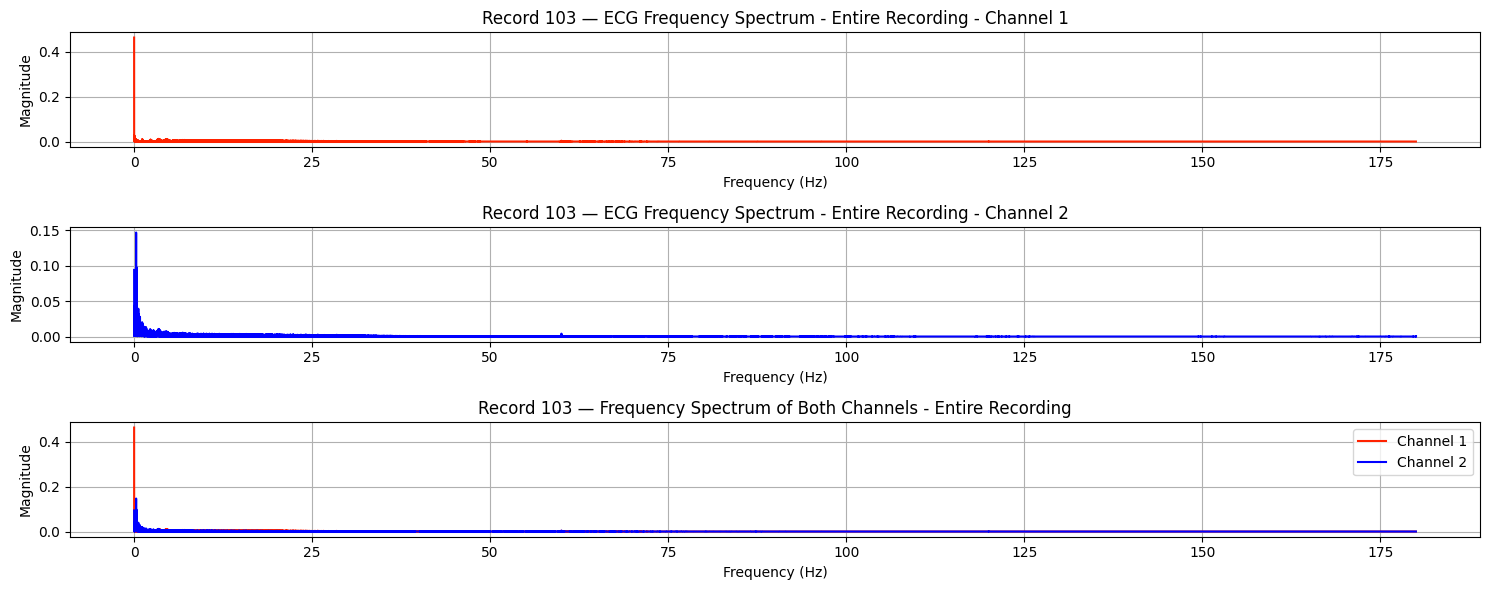

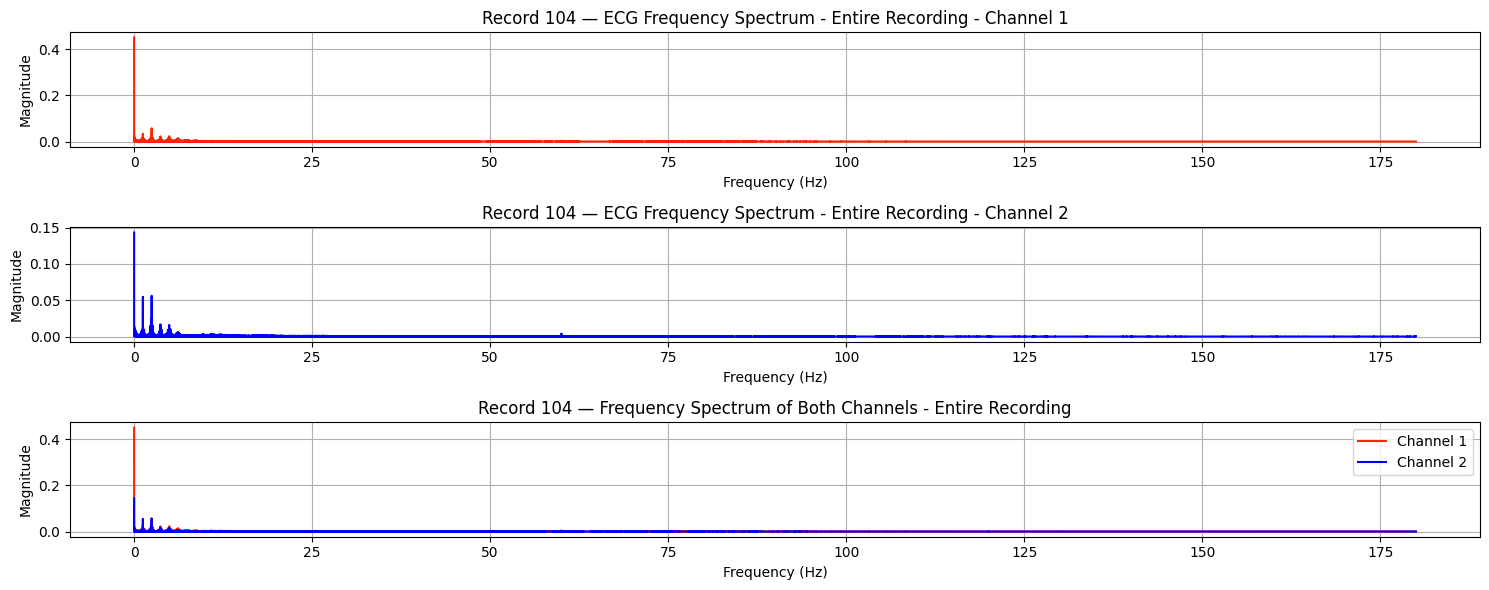

In [81]:
start = 0
end = (records[0].sig_len/records[0].fs)

plot_freq_spectrum(records[0], start, end)
plot_freq_spectrum(records[1], start, end)
plot_freq_spectrum(records[2], start, end)
plot_freq_spectrum(records[3], start, end)
plot_freq_spectrum(records[4], start, end)

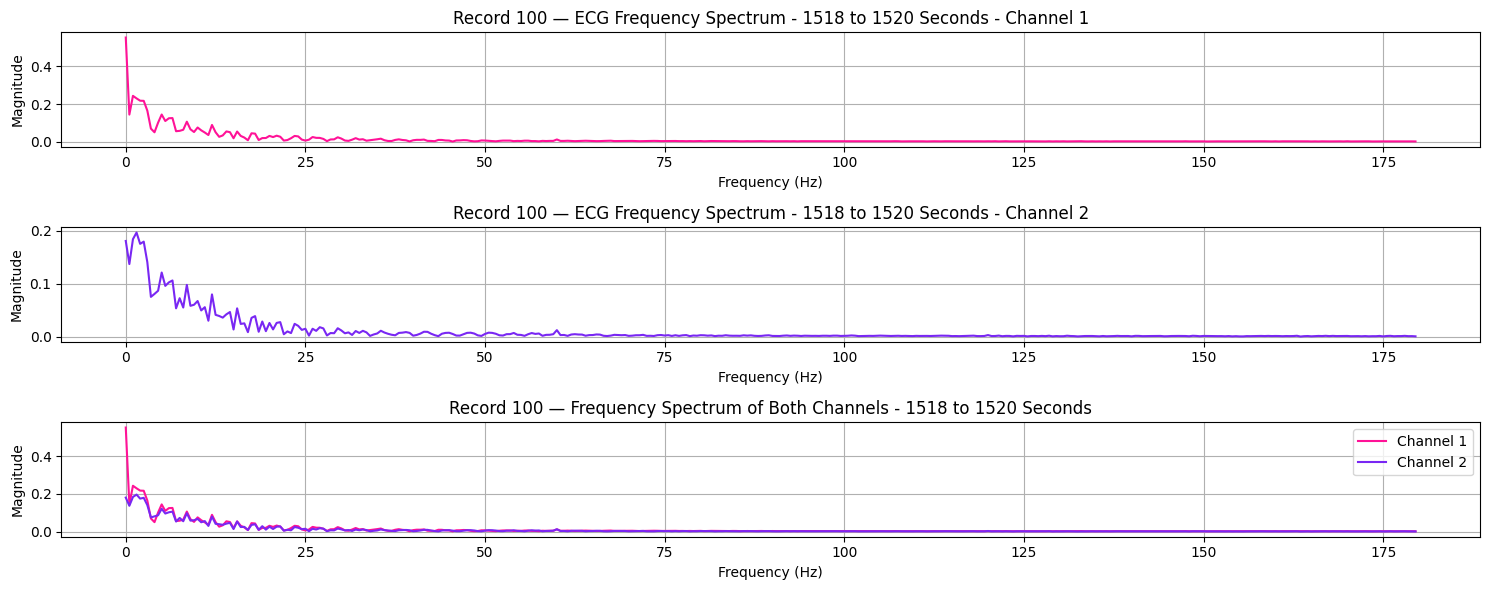

In [82]:
# Specific areas of record 100
plot_freq_spectrum(records[0], 1518, 1520, "#ff1297", "#7927f3")

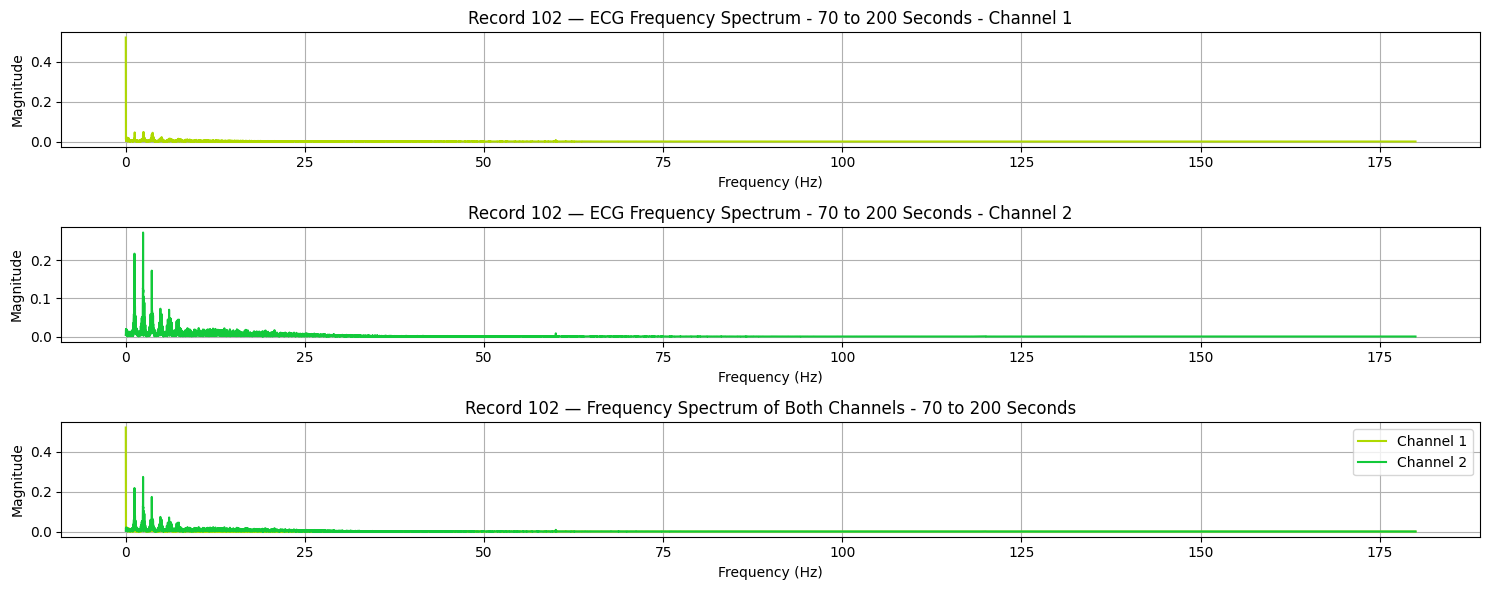

In [83]:
# Specific areas of record 102
plot_freq_spectrum(records[2], 70, 200, "#AED900", "#12c93a")

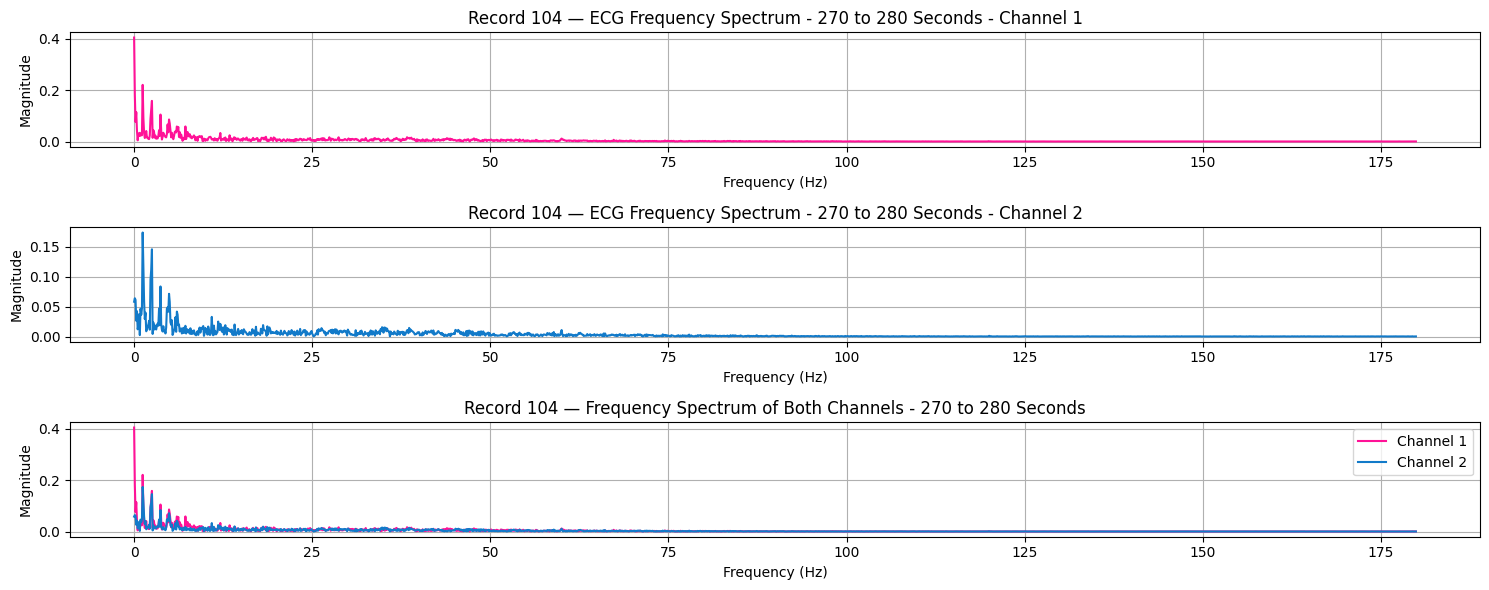

In [84]:
# Specific areas of record 104
plot_freq_spectrum(records[4], 270, 280, "#ff1297", "#127ac9")

## 5. Noise and Artifact Investigation
The examined ECG recordings contain several types of signal variations and potential artifacts:

- Baseline wander: Slow changes in the ECG baseline were observed in some recordings, particularly Records 100 and 101, indicating low-frequency variations.
- High-frequency fluctuations: Rapid, small-amplitude variations were observed in some localized segments and may be associated with noise or transient interference.
- Power-line interference: No prominent narrow spectral peak around 50/60 Hz was observed in the examined recordings; therefore, significant power-line interference was not evident.
- Transient artifacts: Sudden jumps, drops, and irregular fluctuations were observed in some segments. These are broadband transient events and should not automatically be classified as high-frequency noise or removed using a conventional filter.
- Physiological variability: Differences in amplitude, baseline, and morphology across recordings and channels were observed. Unusual waveform characteristics should therefore be distinguished from actual artifacts before applying filtering.

## 6. Filtering Experiments

In [43]:
# High pass filter
#--------------------
def high_pass_filter(signal, cutoff_freq, record, order=2):
    # Build the filter
    b, a = butter(order, cutoff_freq, btype="high", fs=record.fs)
    # Apply the filter
    return filtfilt(b, a, signal)

In [11]:
def plot_comparison(time, org_sig, filtered_sig, txt):
    plt.figure(figsize=(15, 10))

    plt.subplot(3, 1, 1)
    plt.plot(time, org_sig, 'b', linewidth=1)
    plt.title("1. Input ECG Signal", fontsize=12)
    plt.ylabel("Amplitude (mV)")
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 1, 2)
    plt.plot(time, filtered_sig, 'r', linewidth=1)
    plt.title(f"2. Filtered Signal ({txt})", fontsize=12)
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 1, 3)
    plt.plot(time, org_sig, 'b', linewidth=1, label="Original Signal")
    plt.plot(time, filtered_sig, 'r', linewidth=1, label= "Filtered Signal")
    plt.title(f"3. Original & Filtered Signals ({txt})", fontsize=12)
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)

    plt.legend()
    plt.tight_layout()
    plt.show()


In [12]:
def plot_frequency_comparison(org_sig, filtered_sig, record, txt):
    freq_org, mag_org, pos_org = fft_analysis(org_sig, record)
    freq_filt, mag_filt, pos_filt = fft_analysis(filtered_sig, record)

    plt.figure(figsize=(15, 10))

    plt.subplot(3, 1, 1)
    plt.plot(freq_org[pos_org], mag_org[pos_org], 'b', linewidth=1)
    plt.title("1. Original Signal — Frequency Spectrum", fontsize=12)
    plt.ylabel("Magnitude")
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 1, 2)
    plt.plot(freq_filt[pos_filt], mag_filt[pos_filt], 'r', linewidth=1)
    plt.title(f"2. Filtered Signal — Frequency Spectrum ({txt})", fontsize=12)
    plt.ylabel("Magnitude")
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 1, 3)
    plt.plot(freq_org[pos_org], mag_org[pos_org], 'b', linewidth=1, label="Original Signal")
    plt.plot(freq_filt[pos_filt], mag_filt[pos_filt], 'r', linewidth=1, label="Filtered Signal")
    plt.title(f"3. Original & Filtered — Frequency Spectrum ({txt})", fontsize=12)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

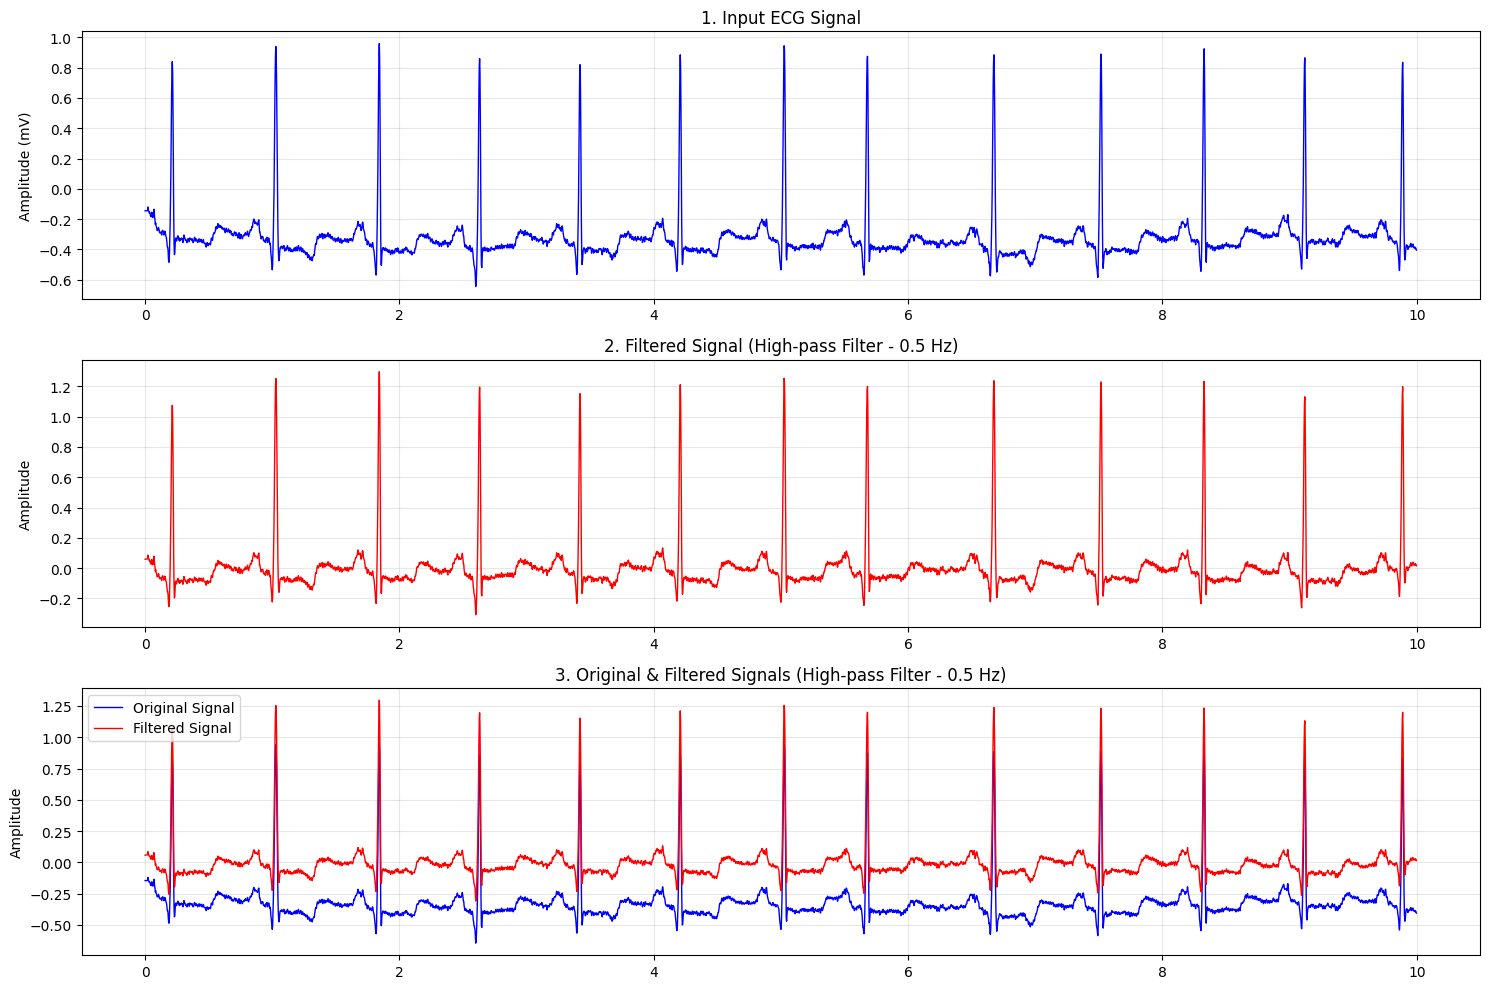

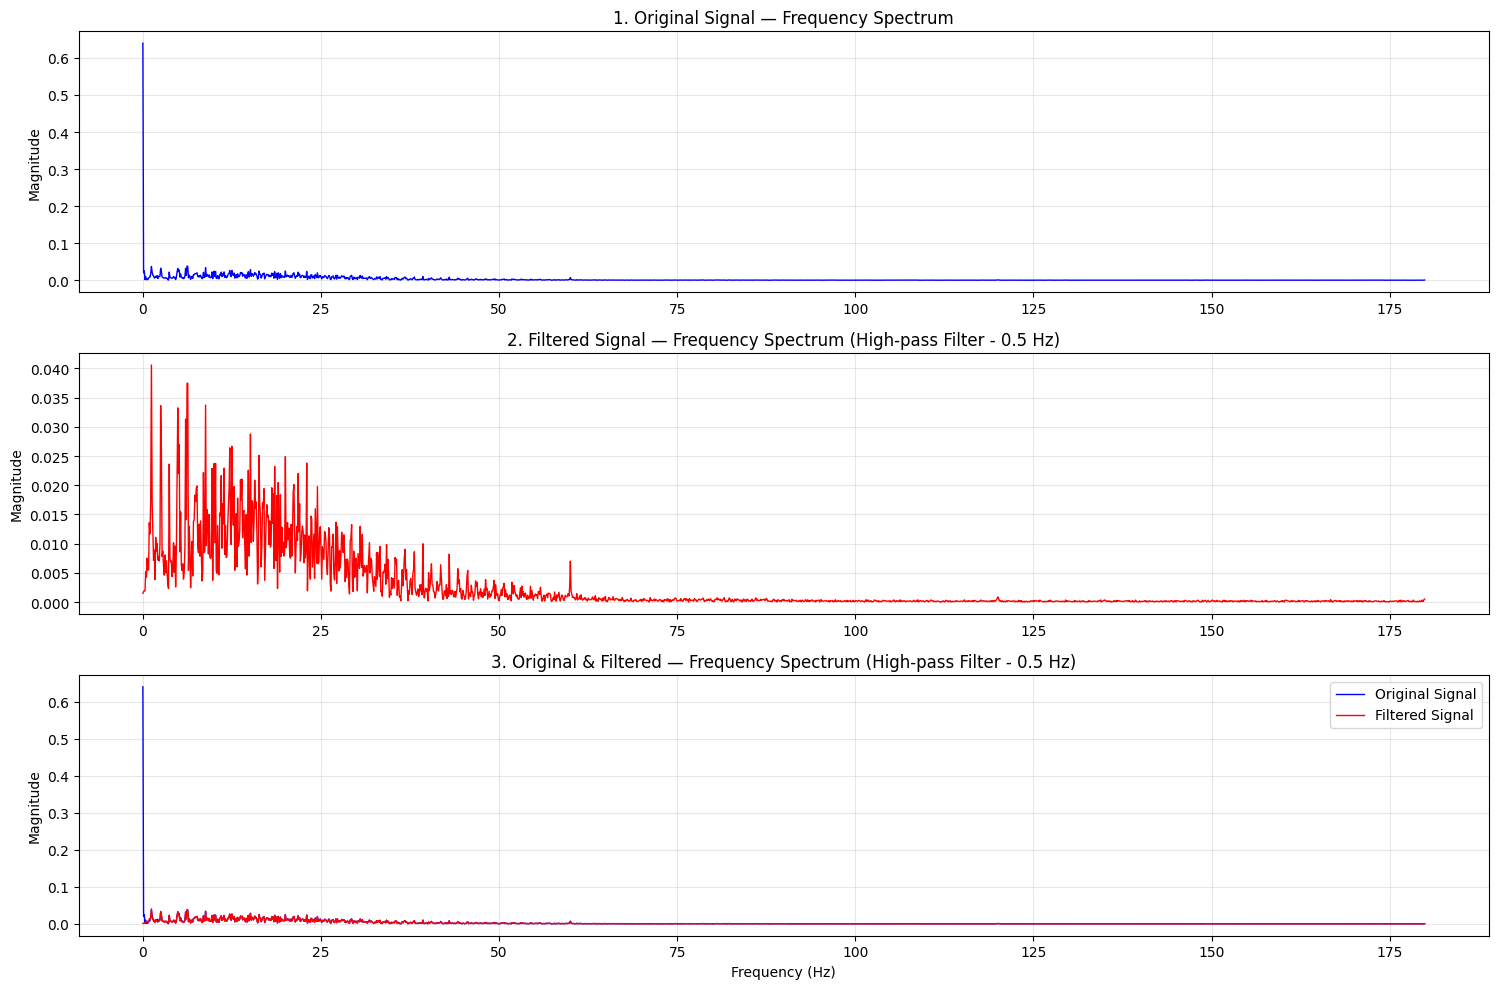

In [113]:
# Apply hp filter on record 100 channel 1; 10 seconds
filtered_sig_100 = high_pass_filter(records[0].p_signal[:3600, 0], 0.5, records[0]) 
plot_comparison(time_100[:3600], records[0].p_signal[:3600, 0], filtered_sig_100, "High-pass Filter - 0.5 Hz")
plot_frequency_comparison(records[0].p_signal[:3600, 0], filtered_sig_100, records[0], "High-pass Filter - 0.5 Hz")

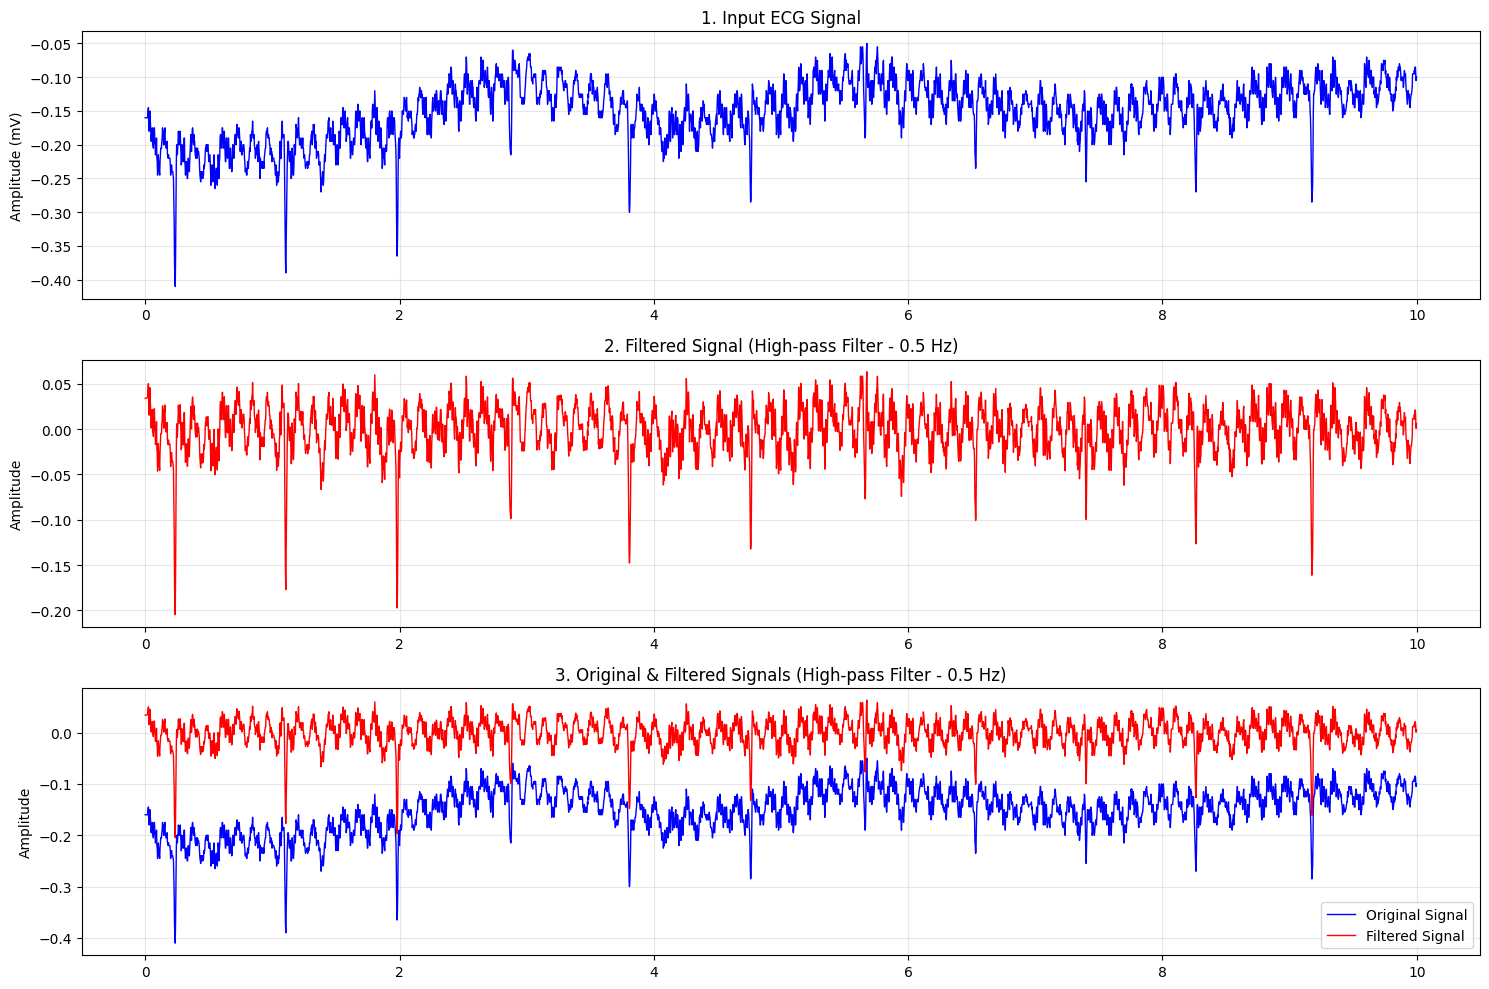

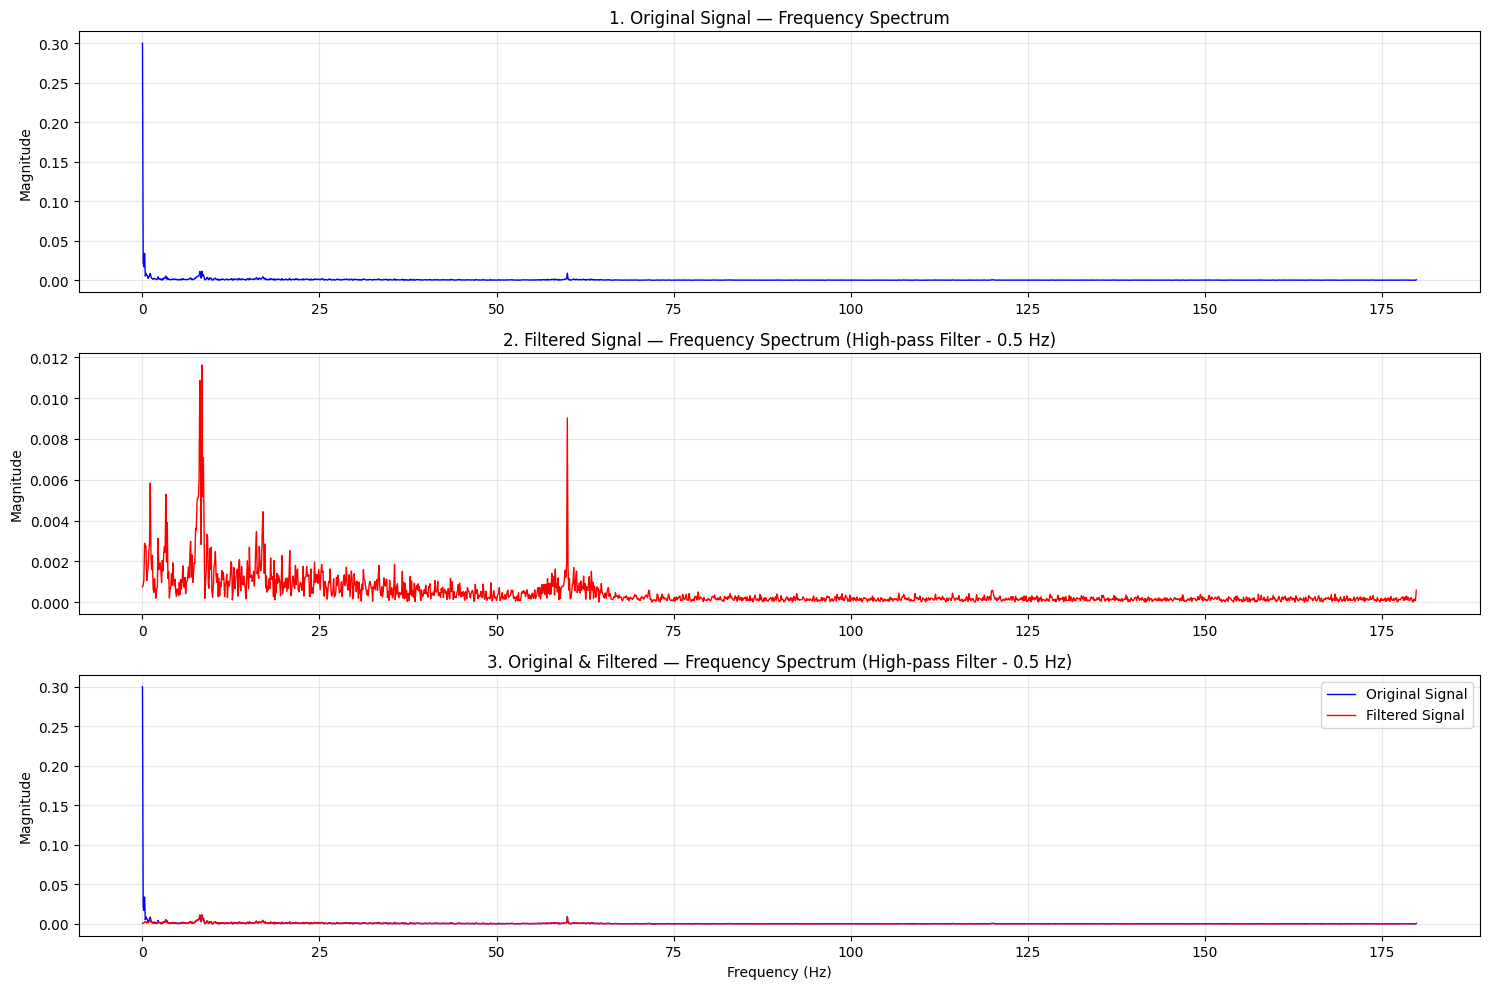

In [18]:
# Apply hp filter on record 101 channel 2; 10 seconds
filtered_sig_101 = high_pass_filter(records[1].p_signal[:3600, 1], 0.5, records[1]) 
plot_comparison(time_102[:3600], records[1].p_signal[:3600, 1], filtered_sig_101, "High-pass Filter - 0.5 Hz")
plot_frequency_comparison(records[1].p_signal[:3600, 1], filtered_sig_101, records[1], "High-pass Filter - 0.5 Hz")

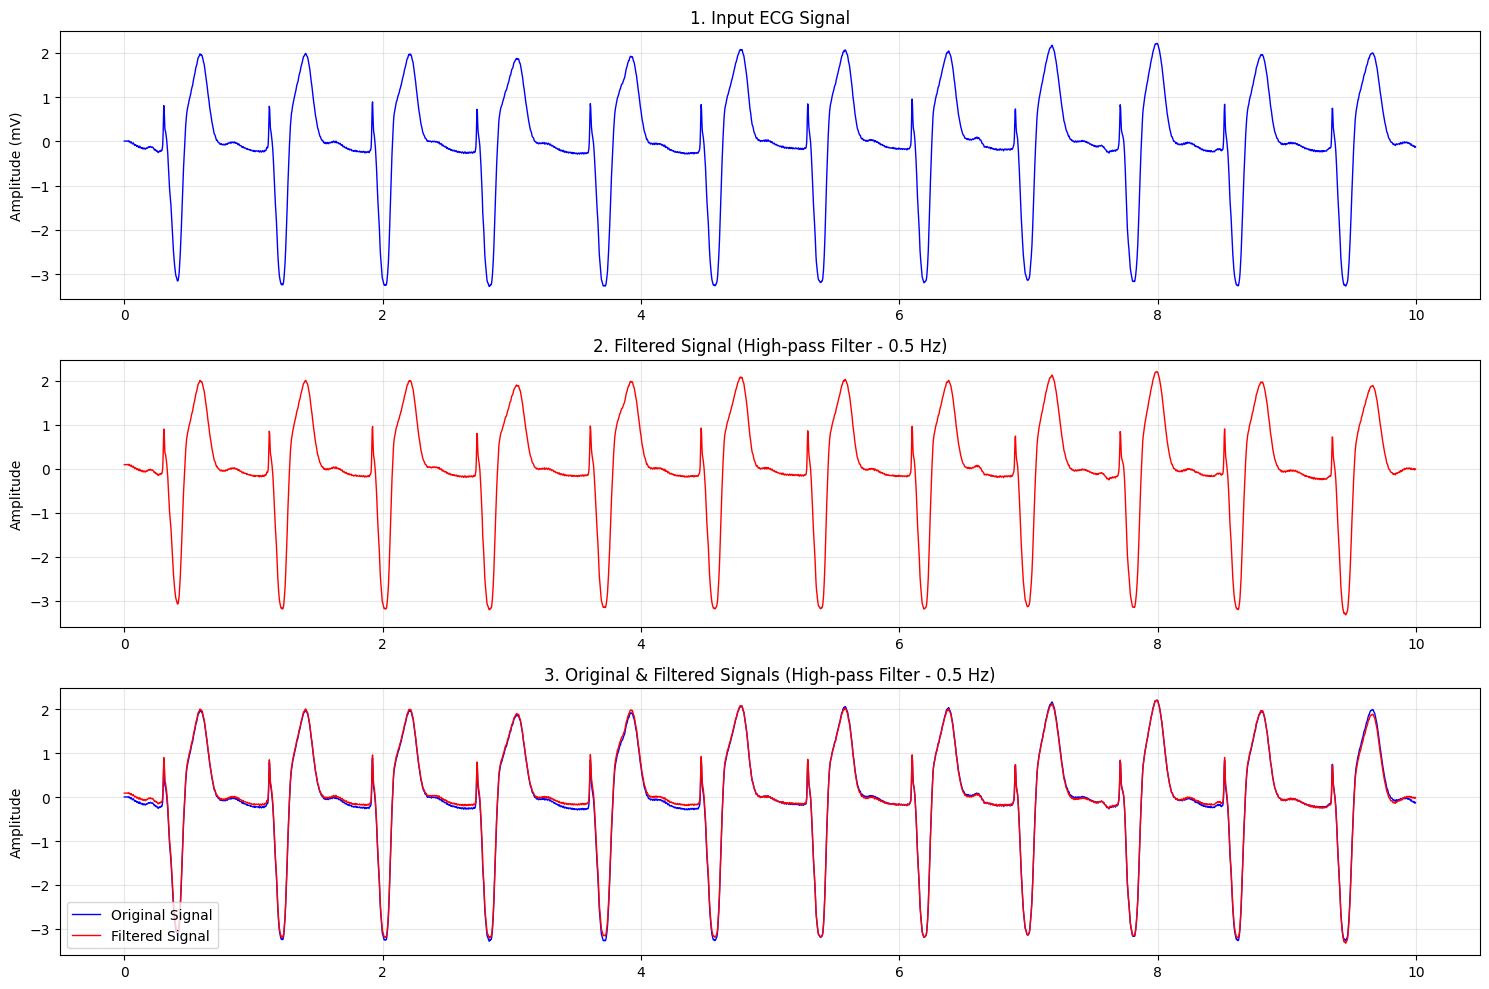

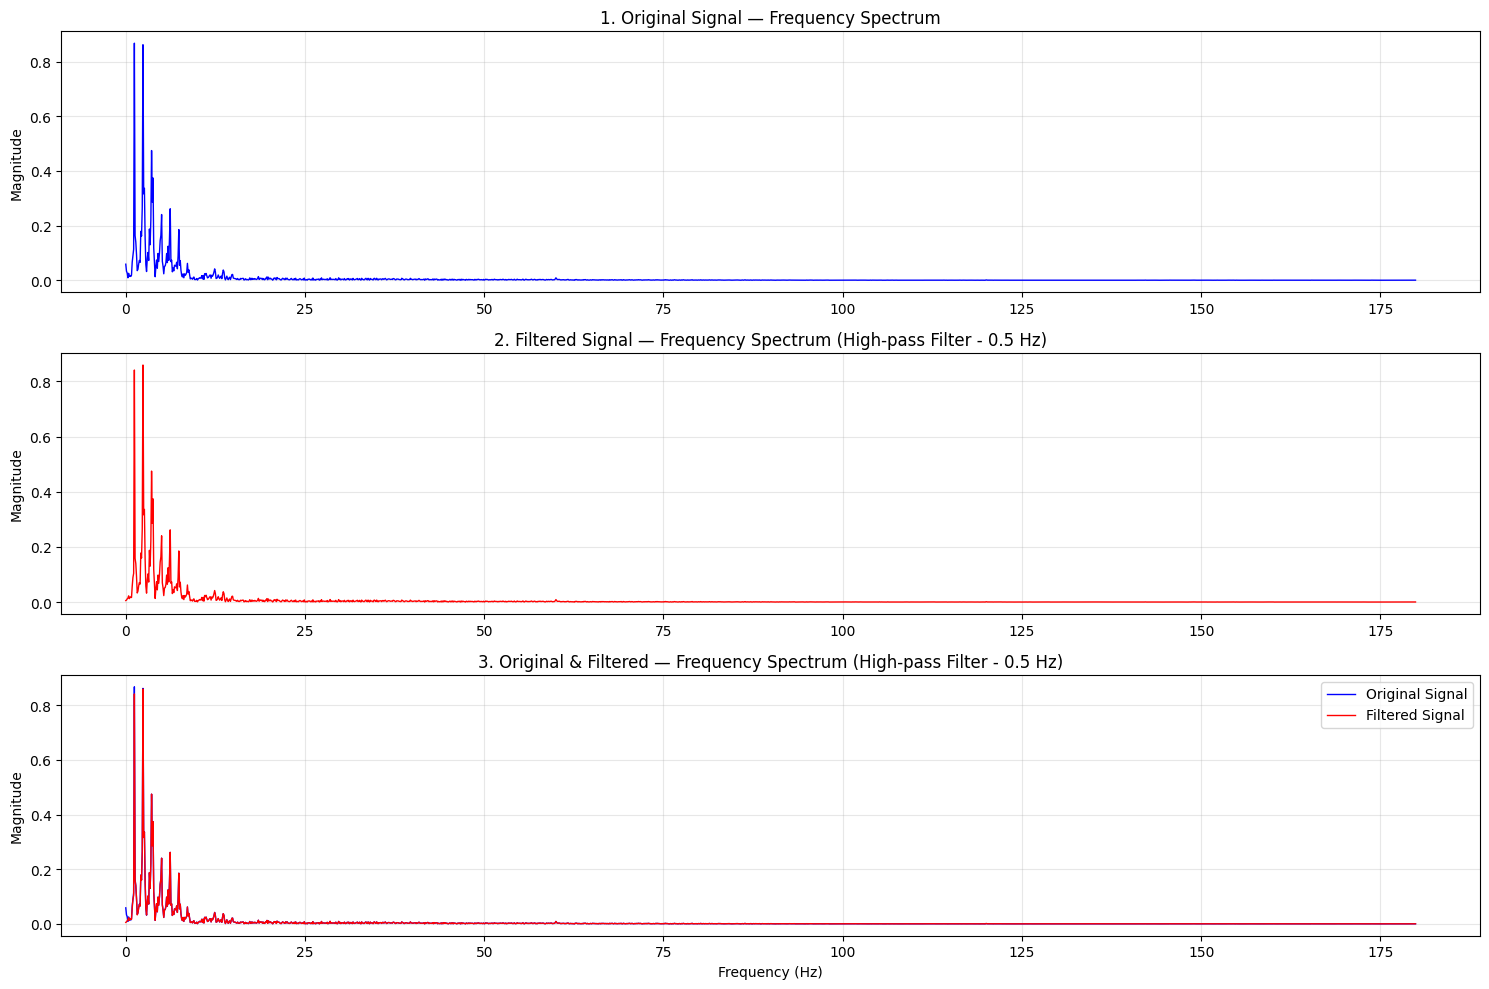

In [114]:
# Apply hp filter on record 102 channel 2; 10 seconds
filtered_sig_102 = high_pass_filter(records[2].p_signal[:3600, 1], 0.5, records[2]) 
plot_comparison(time_102[:3600], records[2].p_signal[:3600, 1], filtered_sig_102, "High-pass Filter - 0.5 Hz")
plot_frequency_comparison(records[2].p_signal[:3600, 1], filtered_sig_102, records[2], "High-pass Filter - 0.5 Hz")

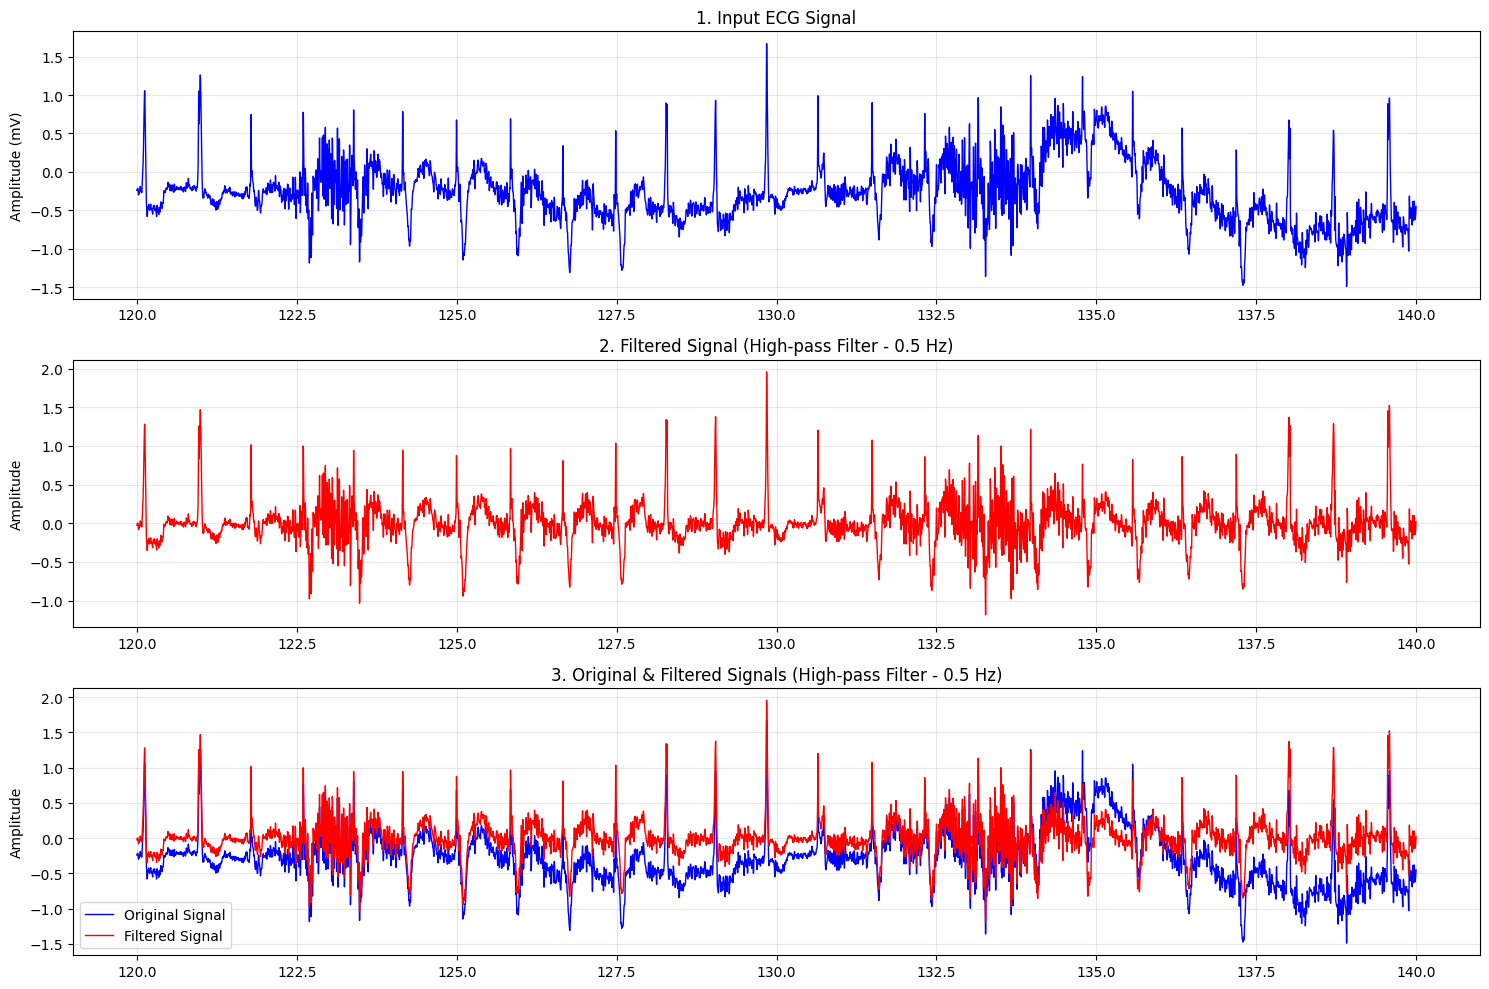

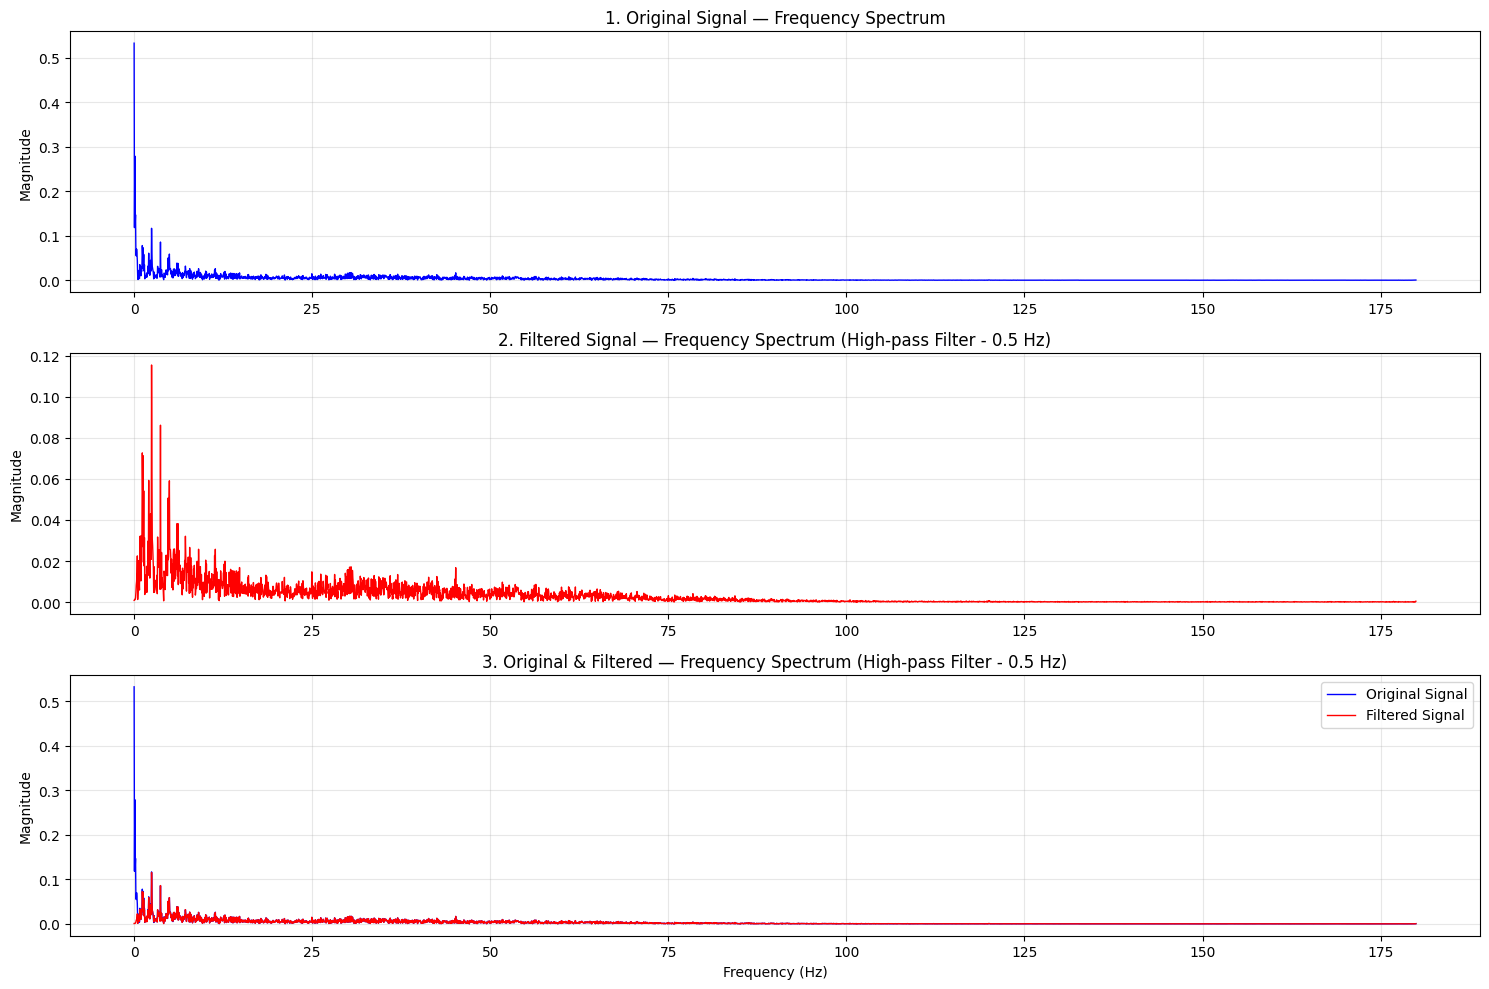

In [33]:
# Apply hp filter on record 104 channel 1; from 120 to 140 seconds
t_104_1 = 120 * 360
t_104_2 = 140 * 360

filtered_sig_104 = high_pass_filter(records[4].p_signal[t_104_1:t_104_2, 0], 0.5, records[4]) 
plot_comparison(time_104[t_104_1:t_104_2], records[4].p_signal[t_104_1:t_104_2, 0], filtered_sig_104, "High-pass Filter - 0.5 Hz")
plot_frequency_comparison(records[4].p_signal[t_104_1:t_104_2, 0], filtered_sig_104, records[4], "High-pass Filter - 0.5 Hz")

In [13]:
# Low pass filter
#--------------------
def low_pass_filter(signal, cutoff_freq, record, order=2):
    # Build the filter
    b, a = butter(order, cutoff_freq, btype="low", fs=record.fs)
    # Apply the filter
    return filtfilt(b, a, signal)

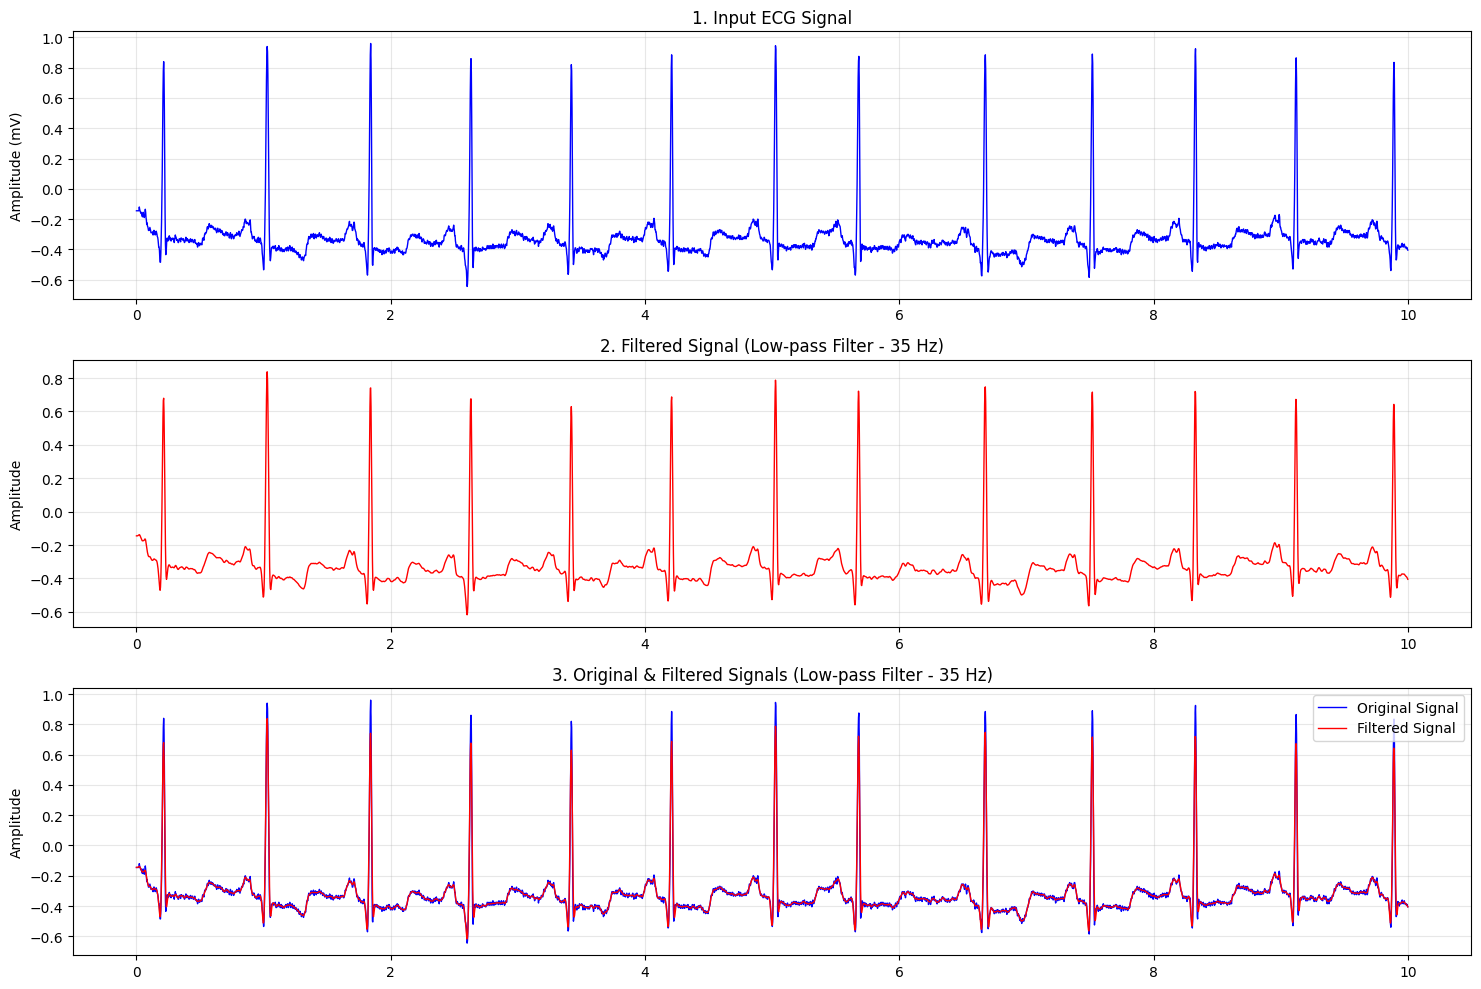

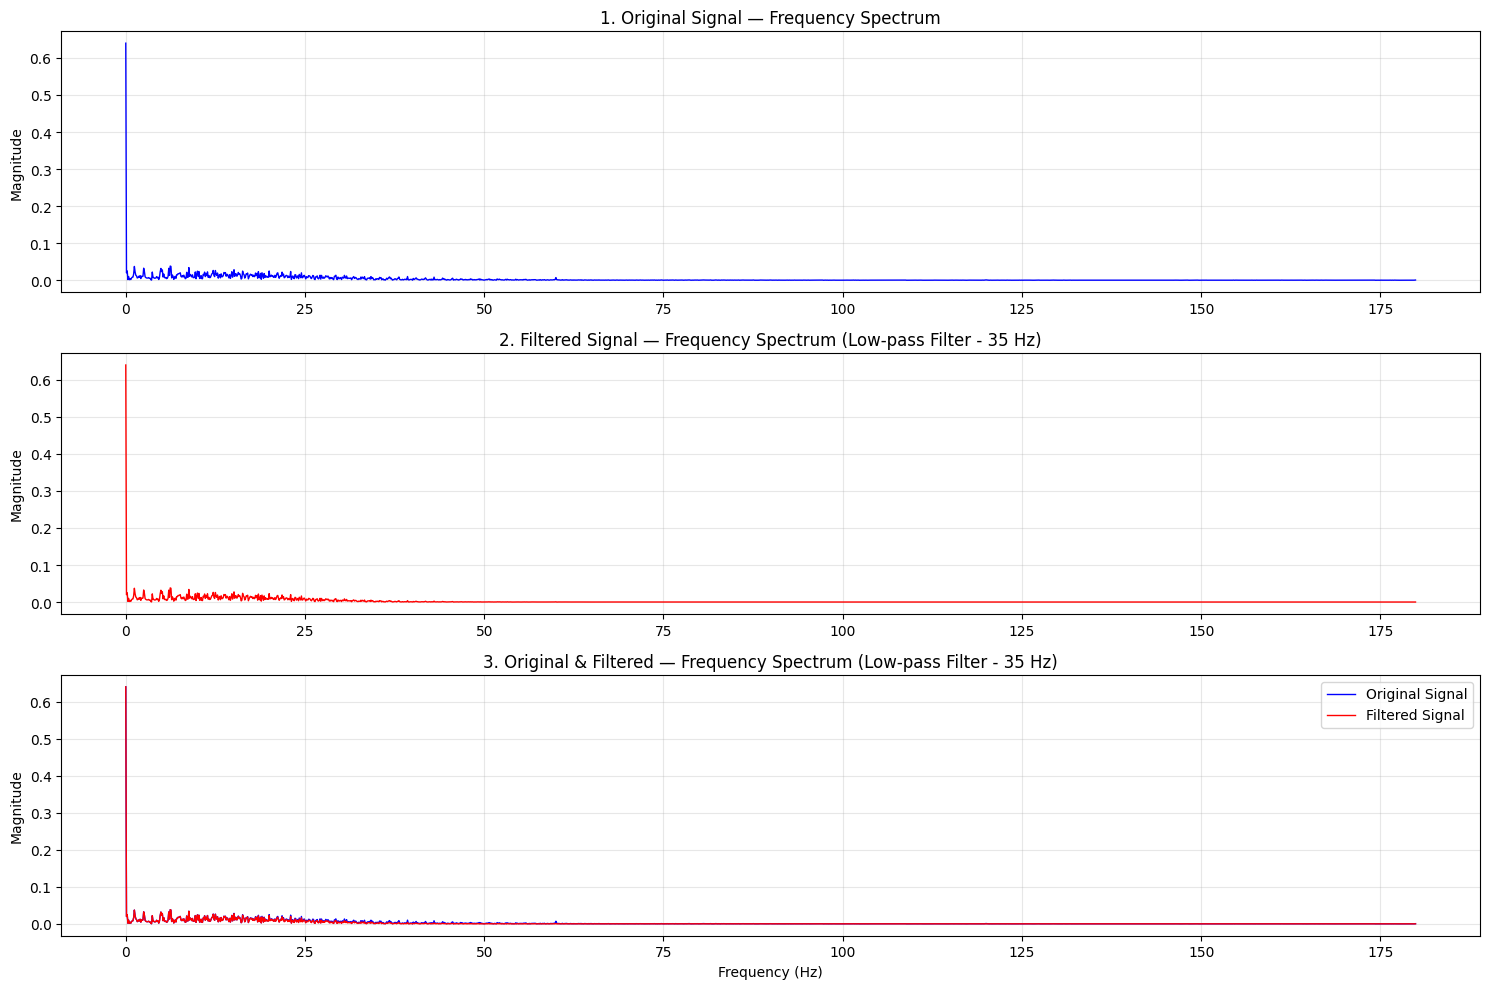

In [41]:
# Apply lp filter on record 100 channel 1; 10 seconds
filtered_sig_100_lp = low_pass_filter(records[0].p_signal[:3600, 0], 35, records[0]) 
plot_comparison(time_100[:3600], records[0].p_signal[:3600, 0], filtered_sig_100_lp, "Low-pass Filter - 35 Hz")
plot_frequency_comparison(records[0].p_signal[:3600, 0], filtered_sig_100_lp, records[0], "Low-pass Filter - 35 Hz")

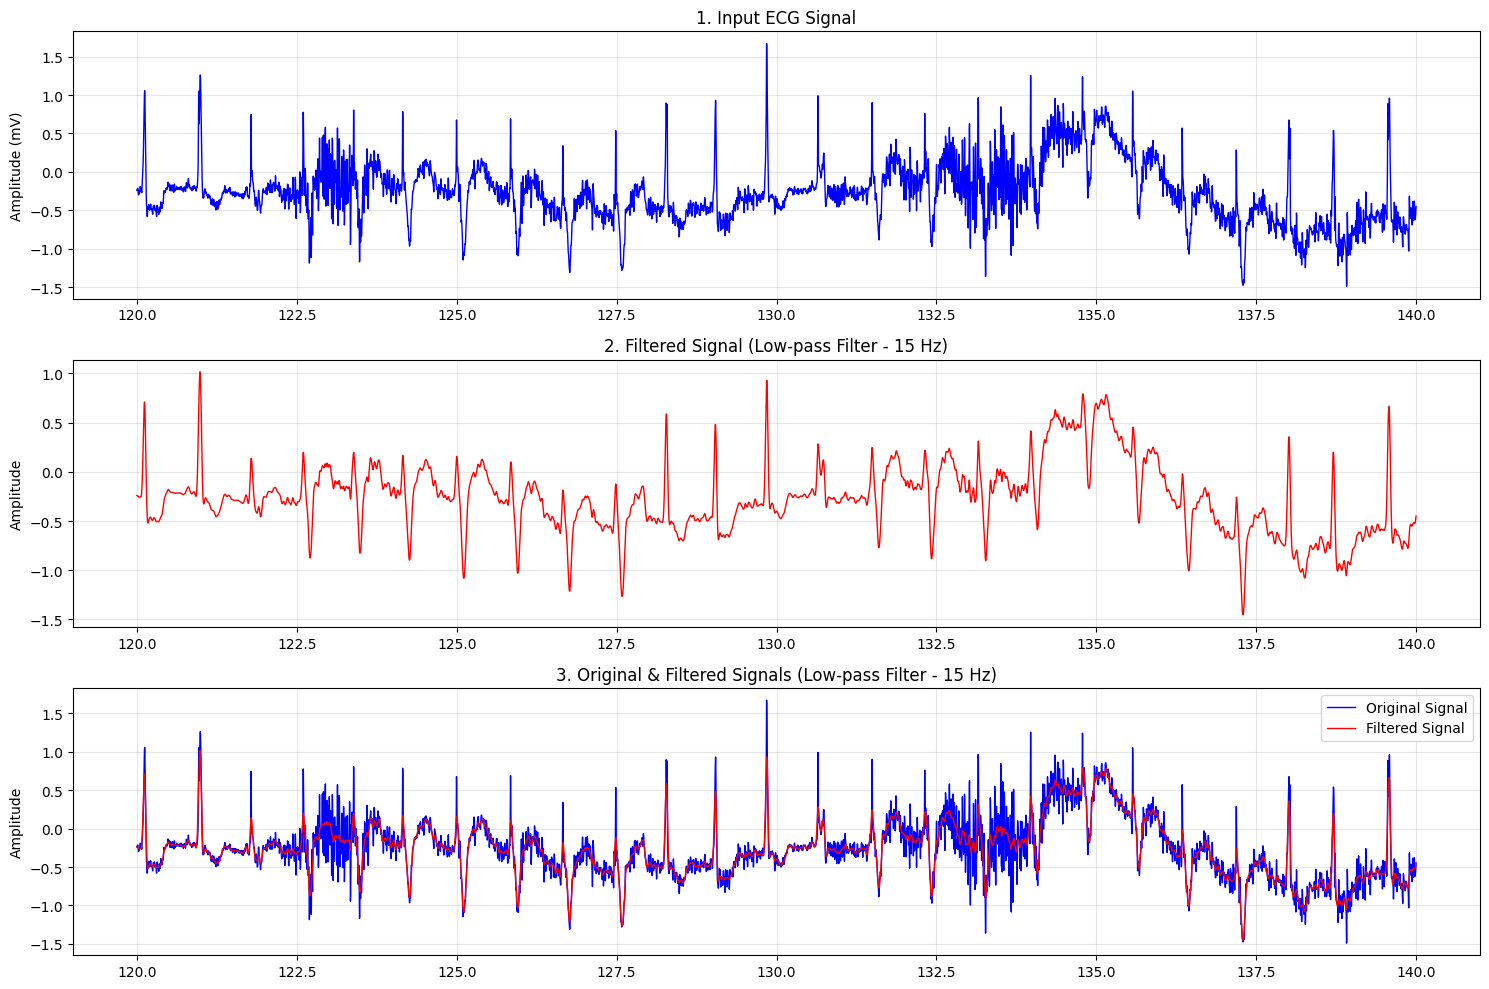

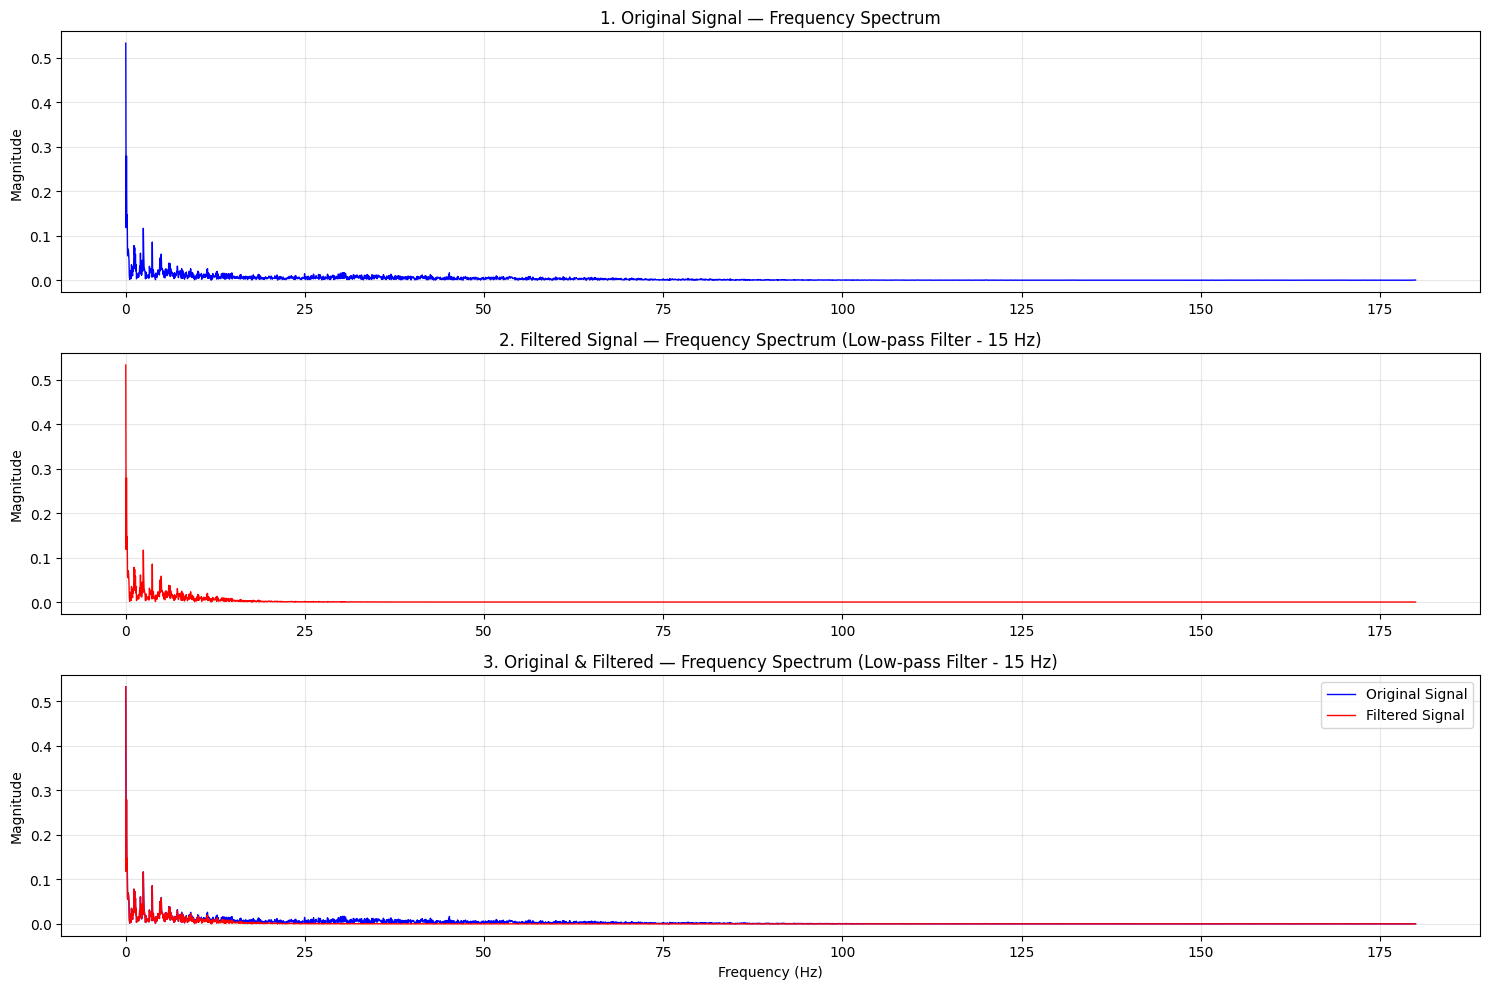

In [ ]:
# Apply hp filter on record 104 channel 1; from 120 to 140 seconds
filtered_sig_104_lp = low_pass_filter(records[4].p_signal[t_104_1:t_104_2, 0], 15, records[4]) 
plot_comparison(time_104[t_104_1:t_104_2], records[4].p_signal[t_104_1:t_104_2, 0], filtered_sig_104_lp, "Low-pass Filter - 15 Hz")
plot_frequency_comparison(records[4].p_signal[t_104_1:t_104_2, 0], filtered_sig_104_lp, records[4], "Low-pass Filter - 15 Hz")

In [44]:
# band pass filter
#--------------------
def band_pass_filter(signal, cutoff_freqs:list, record, order=2):
    # Build the filter
    b, a = butter(order, cutoff_freqs, btype="bandpass", fs=record.fs)
    # Apply the filter
    return filtfilt(b, a, signal)

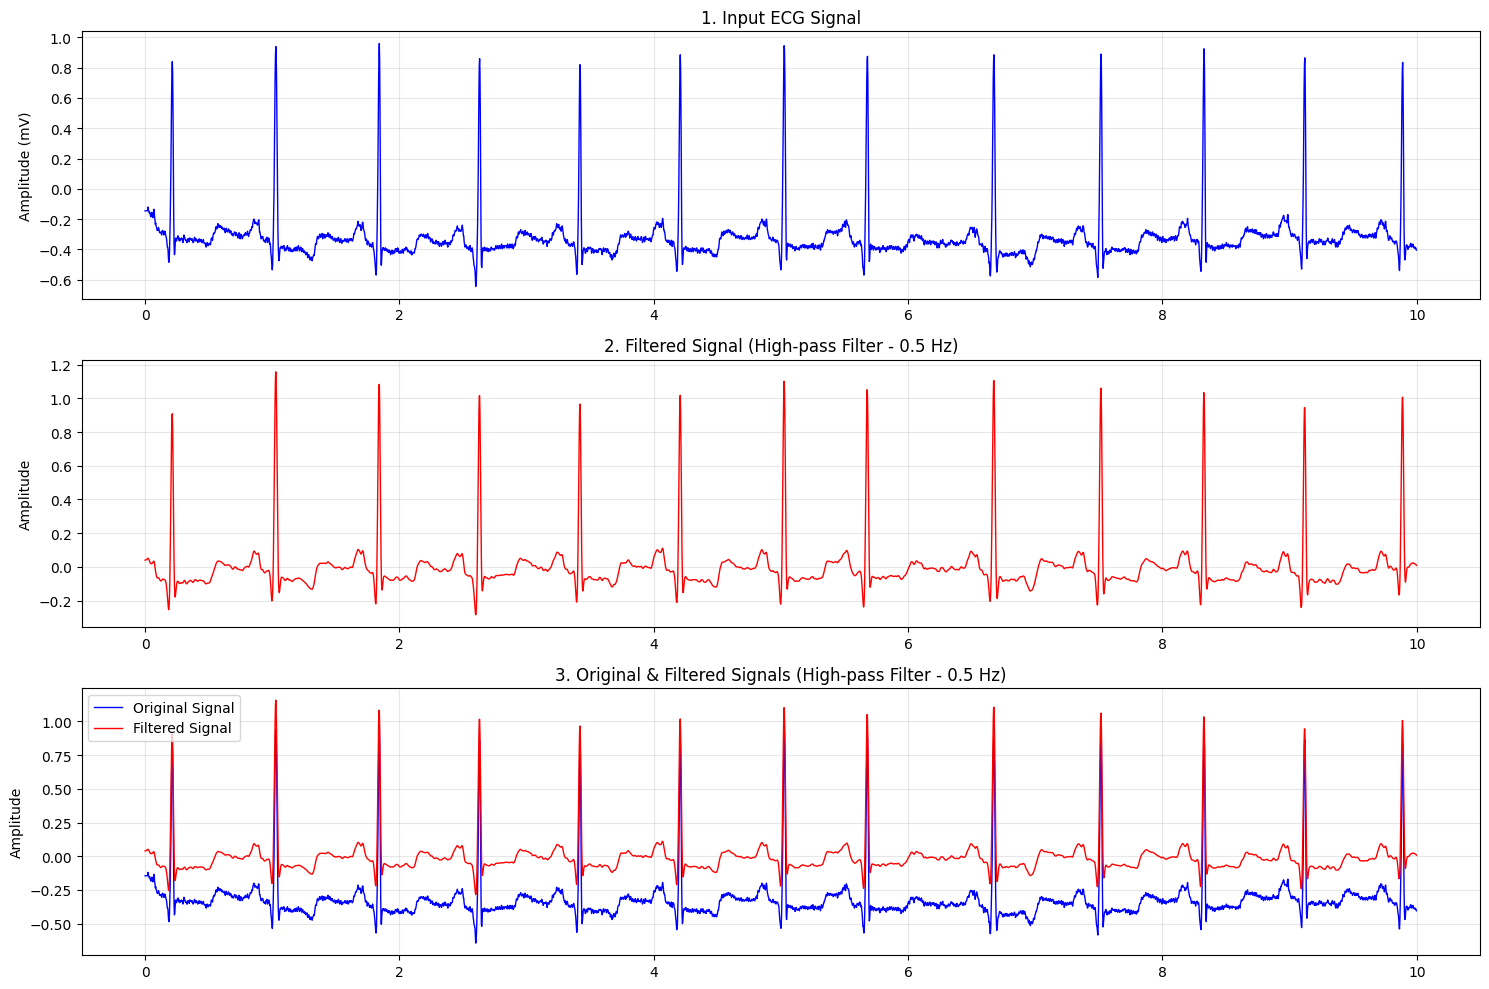

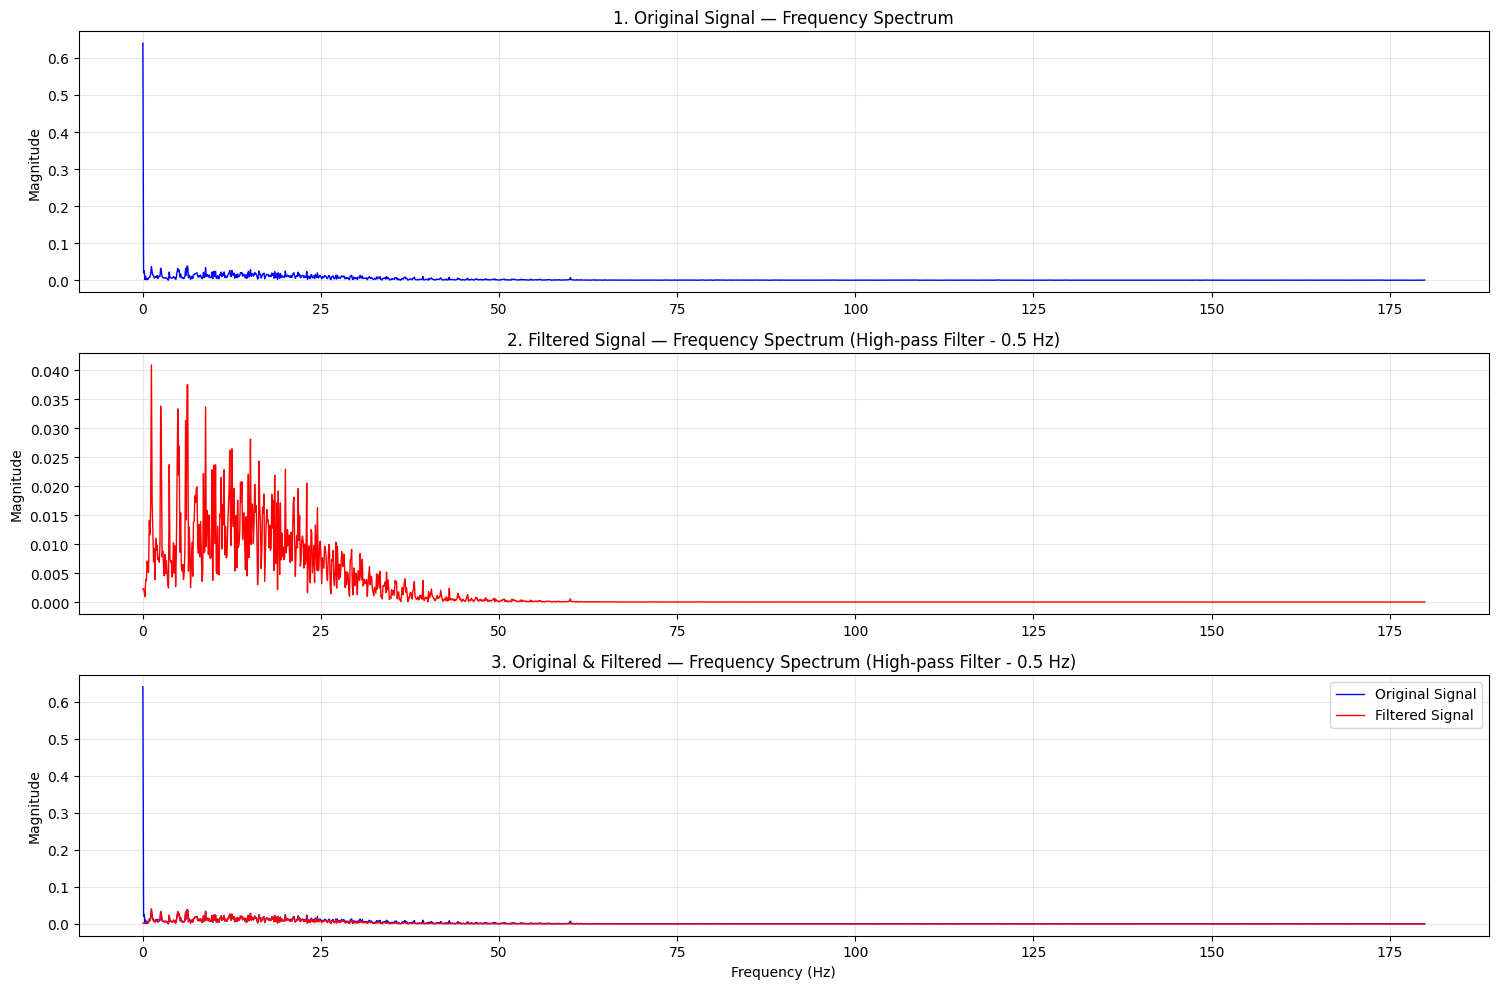

In [ ]:
# Apply hp filter on record 100 channel 1; 10 seconds
filtered_sig_100_bandpass = band_pass_filter(records[0].p_signal[:3600, 0], [0.5, 35], records[0]) 
plot_comparison(time_100[:3600], records[0].p_signal[:3600, 0], filtered_sig_100_bandpass, "Band-pass Filter - 0.5-35 Hz")
plot_frequency_comparison(records[0].p_signal[:3600, 0], filtered_sig_100_bandpass, records[0], "Band-pass Filter - 0.5-35 Hz")

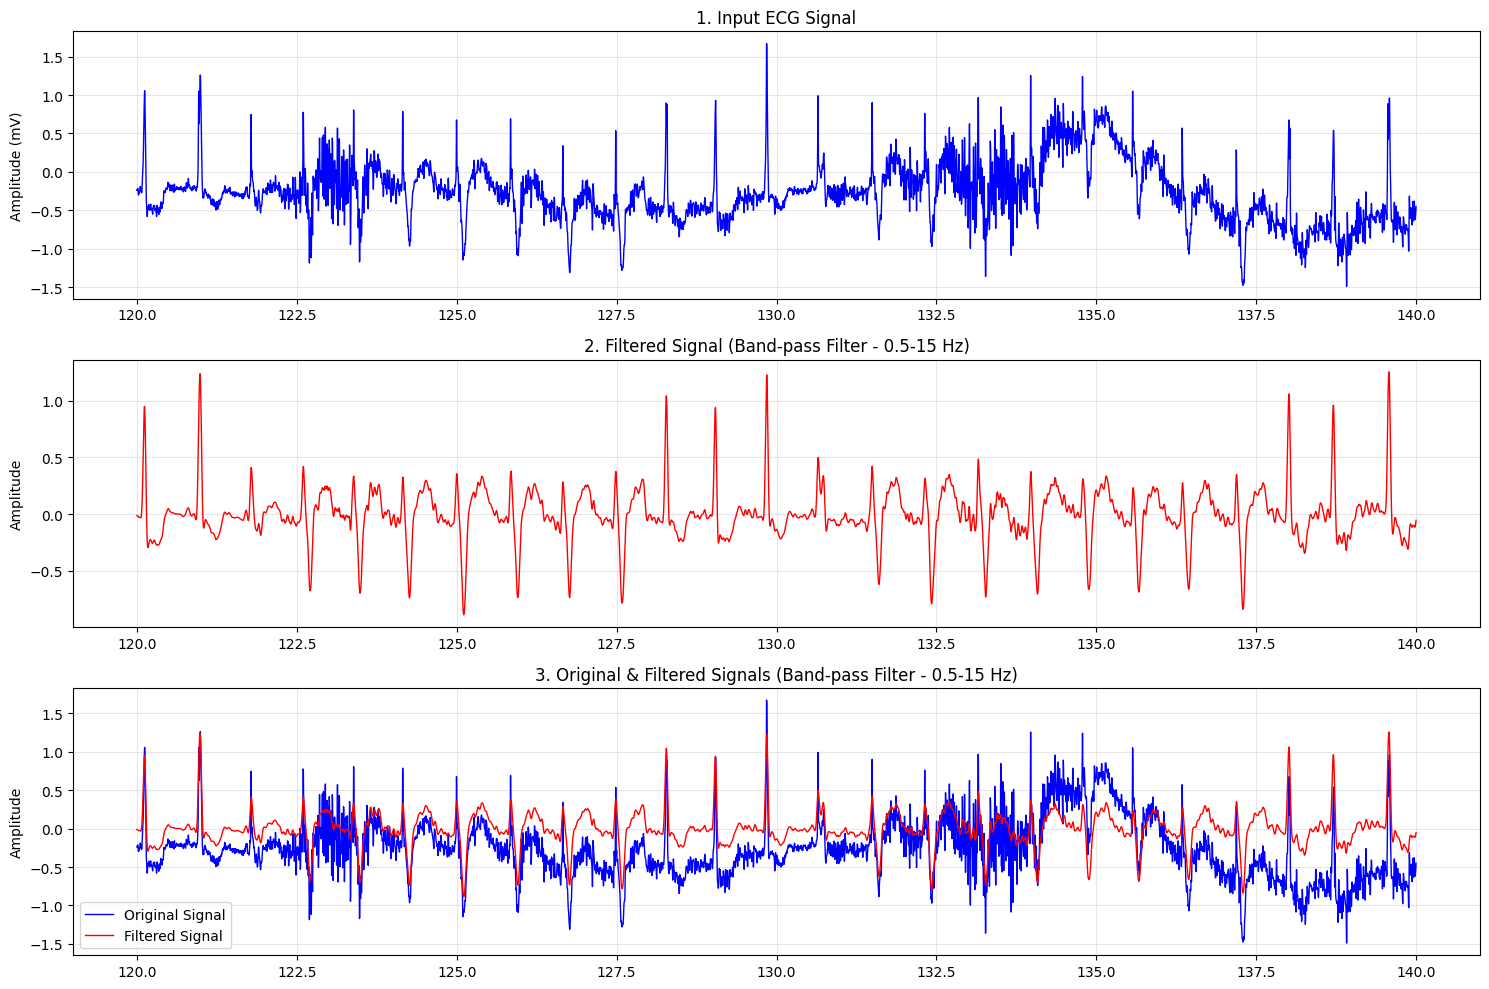

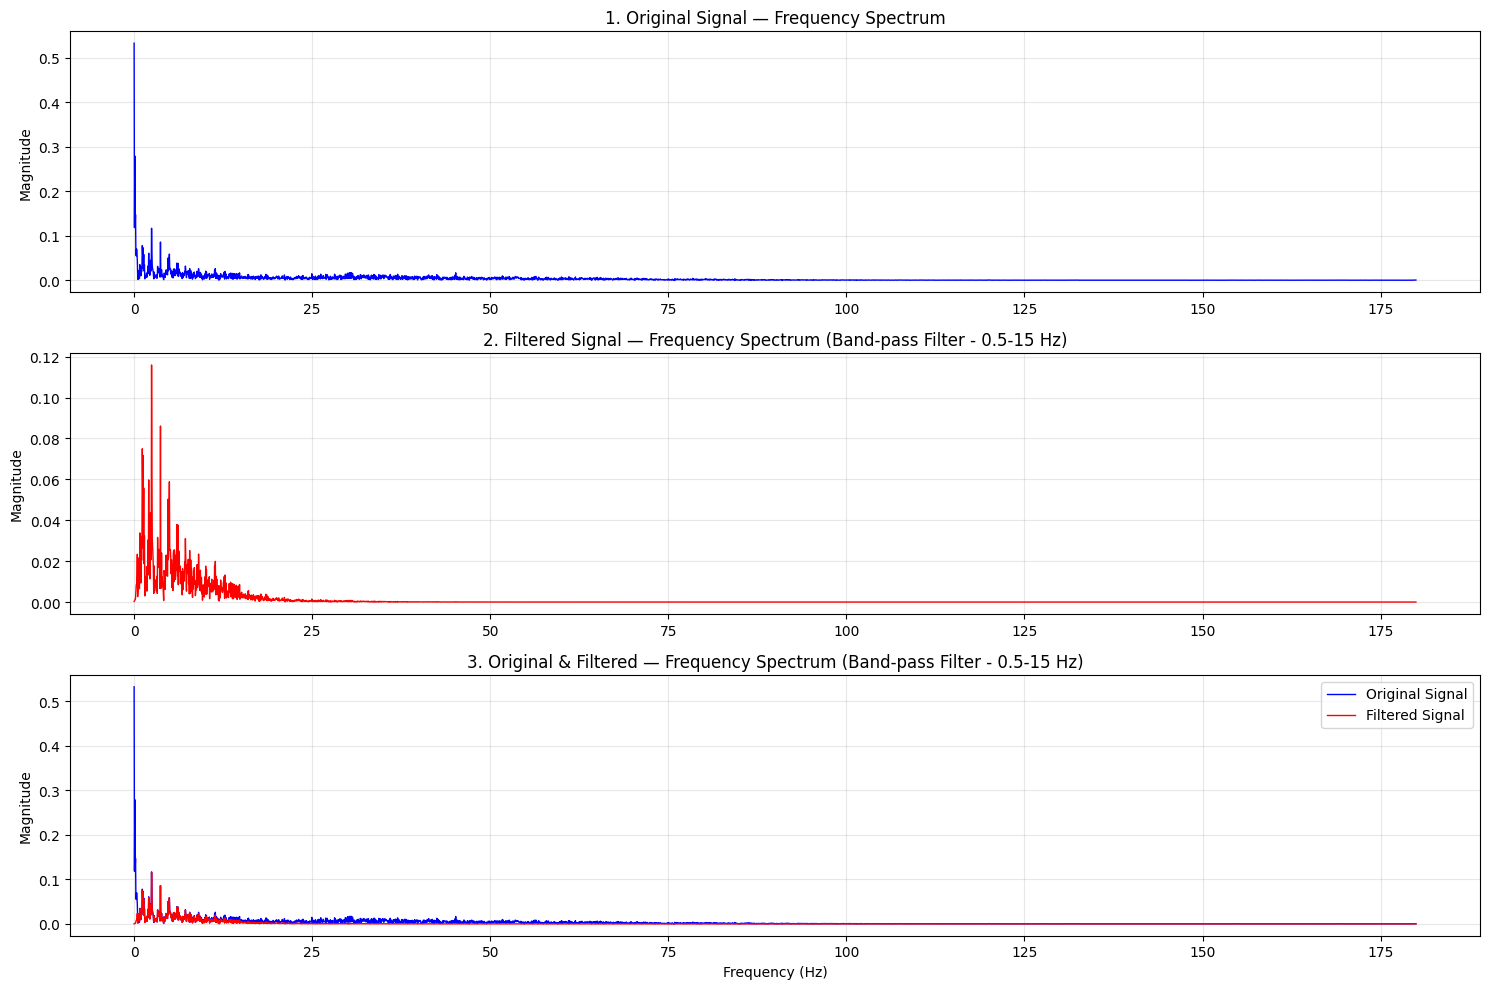

In [50]:
# Apply hp filter on record 104 channel 1; from 120 to 140
filtered_sig_104_bandpass = band_pass_filter(records[4].p_signal[t_104_1:t_104_2, 0], [0.5, 15], records[4]) 
plot_comparison(time_100[t_104_1:t_104_2], records[4].p_signal[t_104_1:t_104_2, 0], filtered_sig_104_bandpass, "Band-pass Filter - 0.5-15 Hz")
plot_frequency_comparison(records[4].p_signal[t_104_1:t_104_2, 0], filtered_sig_104_bandpass, records[4], "Band-pass Filter - 0.5-15 Hz")